# AutoValue AI: предсказание стоимости автомобиля и контроль риска переплаты

**Заказчик:** стартап AutoValue AI, мобильное приложение для мгновенной оценки автомобиля с пробегом.

**Проблема.** Приложение называет клиенту цену выкупа автоматически, без осмотра экспертом.
Ошибка стоит денег в обе стороны, но по-разному:

* **завышение** - компания выкупает машину дороже рынка и не может перепродать её без убытка;
* **занижение** - клиент уходит к конкуренту, сделка не состоялась, это упущенная выручка.

**Цель проекта.** Провести турнир трёх библиотек градиентного бустинга (XGBoost, CatBoost,
LightGBM) на одних и тех же данных, выбрать самую эффективную, минимизировать финансовые риски
и объяснить бизнесу, на чём модель строит оценку.

**Данные:** `ds_s16_train_data.csv` - 8 000 сделок для обучения, `ds_s16_test_data.csv` - 2 000
сделок для финальной проверки. Целевой признак - `price_rub`, реальная сумма сделки в рублях.

## Постановка задачи в терминах машинного обучения

**Тип задачи:** регрессия. Для каждого автомобиля предсказываем `price_rub` по 12 признакам:
5 числовых (`make_year`, `mileage_kmpl`, `engine_cc`, `owner_count`, `accidents_reported`) и
7 категориальных (`brand`, `fuel_type`, `transmission`, `color`, `service_history`,
`insurance_valid`, `region`).

**Функция потерь - MAE.** Ошибка измеряется в рублях, и штраф должен расти линейно: промах на
100 000 рублей ровно вдвое хуже промаха на 50 000. MSE наказывал бы редкие крупные ошибки
квадратично и заставил бы модель обслуживать дорогой хвост распределения в ущерб массовому
сегменту.

**Метрики качества:**

| Метрика | Смысл расчёта | Что показывает бизнесу |
|---|---|---|
| MAE | среднее абсолютное отклонение | среднюю ошибку оценки в рублях |
| RMSE | корень из среднего квадрата ошибки | чувствительность к крупным промахам |
| R² | доля объяснённой дисперсии | насколько модель лучше константного прогноза |
| Overpricing Rate | доля наблюдений с `(прогноз - факт) / факт > 0.20` | как часто рискуем купить машину дороже рынка |
| Underpricing Loss | сумма `факт - прогноз` там, где `(прогноз - факт) / факт < -0.20` | упущенную выручку в рублях |

**Асимметрия рисков.** Overpricing - это прямой убыток на балансе, Underpricing - недополученная
прибыль. Поэтому выбор модели делаем не по одному MAE, а по комбинации базовых и бизнес-метрик.

**План работы:**

1. **EDA** - распределение цены, корреляции, пропуски и типы данных.
2. **Предобработка** - единое разбиение train/validation для всех библиотек, кодирование
   категорий по правилам каждой библиотеки, тест откладываем до части 6.
3. **Раунд 1 турнира** - три модели на настройках по умолчанию, замер wall time, отдельно
   осторожная модель на квантильном лоссе.
4. **Раунд 2 турнира** - тюнинг каждой библиотеки в Optuna по единой сетке параметров.
5. **Интерпретация** - SHAP, разбор бизнес-рисков, разрез ошибок по маркам и регионам.
6. **Финальная проверка** - лучшая модель на отложенном тесте, контроль переобучения.
7. **Аналитическая записка** для Артёма (CEO) и Юли (Head of Data).

**Итоговая мысль.** Задача сводится к выбору библиотеки, которая при сопоставимом MAE даёт
наименьший риск переплаты: именно переплата напрямую бьёт по марже стартапа.

## Загрузка библиотек

В базовом окружении платформы (Python 3.9, scikit-learn 0.24) нет ни одной библиотеки
градиентного бустинга, поэтому ячейка ниже доустанавливает их и печатает версии. Повторный
запуск ничего не меняет.

Версии подобраны под старый стек платформы: ни одна из них не тянет за собой обновление
`numpy`, `pandas` или `scikit-learn`.

* `xgboost==2.1.4` - здесь проверяется **версия**, а не факт установки. Функция потерь
  `reg:absoluteerror` работает только начиная с ветки 2.0: в более ранних версиях второй
  производной у MAE нет, значения листьев не обновляются и модель вырождается в константу
  (проверено отдельно: R² около нуля, MAE как у прогноза медианой).
* `lightgbm==3.3.5` и `catboost==1.2.5` - ветки, совместимые с `numpy 1.21`.
* `shap==0.44.1` тянет `numba`, поэтому явно фиксируем `numba==0.56.4` - последнюю версию,
  которая работает с `numpy 1.21`.
* `optuna` ставится без пина: ограничений по стеку у неё нет.

Импорт доустанавливаемых библиотек стоит **после** блока установки и выполняется через
`importlib.import_module`: на чистом ядре обычный `import` в начале ячейки упал бы с
`ModuleNotFoundError` раньше, чем отработал бы `pip`.

In [1]:
import importlib
import importlib.util
import site
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version as installed_version

import matplotlib
import numpy
import pandas
import seaborn
import sklearn

# (аргумент для pip, имя модуля, минимальная версия или None, если подойдёт любая)
DEPENDENCIES = [
    ('xgboost==2.1.4', 'xgboost', (2, 0)),
    ('lightgbm==3.3.5', 'lightgbm', None),
    ('catboost==1.2.5', 'catboost', None),
    ('numba==0.56.4', 'numba', None),
    ('shap==0.44.1', 'shap', None),
    ('optuna', 'optuna', None),
]


def needs_install(module, min_version):
    """Ставим пакет, если его нет или установленная версия ниже минимальной.

    Версию читаем из метаданных дистрибутива, а не через import: пакет с
    C-расширением нельзя честно перезагрузить в том же ядре после обновления.
    """
    if importlib.util.find_spec(module) is None:
        return True
    if min_version is None:
        return False
    try:
        current = tuple(int(part) for part in installed_version(module).split('.')[:2])
    except (PackageNotFoundError, ValueError):
        return True
    return current < min_version


installed_now = False
for package, module, min_version in DEPENDENCIES:
    if needs_install(module, min_version):
        print(f'Устанавливаю {package}...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', package], check=True)
        installed_now = True

if installed_now:
    # свежие пакеты попадают в пользовательский site-packages; ставим его в начало
    # sys.path, иначе установленная в системе старая версия останется в приоритете
    user_site = site.getusersitepackages()
    if user_site in sys.path:
        sys.path.remove(user_site)
    sys.path.insert(0, user_site)
    importlib.invalidate_caches()

xgboost = importlib.import_module('xgboost')
lightgbm = importlib.import_module('lightgbm')
catboost = importlib.import_module('catboost')
shap = importlib.import_module('shap')
optuna = importlib.import_module('optuna')

versions = pandas.DataFrame(
    [
        {'библиотека': module.__name__, 'версия': getattr(module, '__version__', 'н/д')}
        for module in (numpy, pandas, sklearn, matplotlib, seaborn,
                       xgboost, lightgbm, catboost, shap, optuna)
    ]
).set_index('библиотека')
versions.columns.name = f'Окружение: Python {sys.version.split()[0]}'
display(versions)

Окружение: Python 3.9.25,версия
библиотека,
numpy,1.21.1
pandas,1.2.4
sklearn,0.24.1
matplotlib,3.3.4
seaborn,0.11.1
xgboost,2.1.4
lightgbm,3.3.5
catboost,1.2.5
shap,0.44.1


In [2]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import shap
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
VAL_SIZE = 0.2       # доля валидации внутри обучающего файла
N_TRIALS = 30        # число испытаний Optuna на каждую библиотеку
# одинаковый бюджет потоков для всех трёх библиотек: иначе замер wall time сравнивал бы
# не алгоритмы, а их настройки многопоточности по умолчанию
N_JOBS = 4
RISK_LIMIT = 0.20    # отклонение, начиная с которого ошибка считается опасной

TARGET = 'price_rub'
NUM_FEATURES = ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported']
CAT_FEATURES = ['brand', 'fuel_type', 'transmission', 'color',
                'service_history', 'insurance_valid', 'region']
FEATURES = NUM_FEATURES + CAT_FEATURES

# **Часть 1. EDA (Экспресс-анализ данных)**

Проведите краткое исследование, чтобы лучше понимать данные.

**Задание 1.1:**

* Данные: загрузите `ds_s16_train_data.csv` (обучение) и `ds_s16_test_data.csv` (финальный тест). Обратите внимание на то, как прописать путь к данным: `/datasets/ds_s16_train_data.csv` и `/datasets/ds_s16_test_data.csv`
* Проведите краткий EDA: изучите распределение целевой переменной (`price_rub`), проверьте корреляции.

---

## 1.1. Загрузка данных

Данные лежат в каталоге `/datasets/` на платформе. Если тетрадь запускается локально,
используется каталог `artifacts/` рядом с тетрадью.

In [3]:
DATA_DIR = Path('/datasets') if Path('/datasets').exists() else Path('artifacts')

train_full = pd.read_csv(DATA_DIR / 'ds_s16_train_data.csv')
test = pd.read_csv(DATA_DIR / 'ds_s16_test_data.csv')

shapes = pd.DataFrame([
    {'выборка': 'train (ds_s16_train_data.csv)',
     'строк': len(train_full), 'столбцов': train_full.shape[1]},
    {'выборка': 'test (ds_s16_test_data.csv)',
     'строк': len(test), 'столбцов': test.shape[1]},
]).set_index('выборка')
display(shapes)
display(train_full.head())

,строк,столбцов
выборка,,
train (ds_s16_train_data.csv),8000,13
test (ds_s16_test_data.csv),2000,13


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


### Типы данных, пропуски и дубликаты

In [4]:
def data_overview(df):
    """Сводка по столбцам: тип, пропуски, число уникальных значений, пример."""
    return pd.DataFrame({
        'тип': df.dtypes.astype(str),
        'пропусков': df.isna().sum(),
        'доля пропусков': df.isna().mean().round(4),
        'уникальных': df.nunique(),
        'пример': df.iloc[0].astype(str),
    })


overview = data_overview(train_full)
overview.columns.name = f'Обучающая выборка: {len(train_full)} строк'
display(overview)

duplicates = pd.DataFrame([
    {'выборка': 'train', 'полных дублей': train_full.duplicated().sum(),
     'дублей без учёта цены': train_full.drop(columns=[TARGET]).duplicated().sum()},
    {'выборка': 'test', 'полных дублей': test.duplicated().sum(),
     'дублей без учёта цены': test.drop(columns=[TARGET]).duplicated().sum()},
]).set_index('выборка')
display(duplicates)

Обучающая выборка: 8000 строк,тип,пропусков,доля пропусков,уникальных,пример
make_year,int64,0,0.0,29,2002
mileage_kmpl,float64,0,0.0,2108,9.7
engine_cc,int64,0,0.0,10,1800
fuel_type,object,0,0.0,3,Diesel
owner_count,int64,0,0.0,5,2
brand,object,0,0.0,10,Hyundai
transmission,object,0,0.0,2,Manual
color,object,0,0.0,6,Silver
service_history,object,0,0.0,3,Partial
accidents_reported,int64,0,0.0,6,0


,полных дублей,дублей без учёта цены
выборка,,
train,0,0
test,0,0


### Вывод: структура данных

* В обучающем файле **8 000 сделок и 13 столбцов**, в тестовом - **2 000 сделок** и те же столбцы.
* **Пропусков нет ни в одном столбце** - импутация не потребуется.
* **Дубликатов нет**: ни полных строк, ни повторов набора признаков без цены (0 в обеих
  выборках). Значит, каждая строка - отдельная сделка, и одинаковых машин с разной ценой,
  которые сбивали бы модель, в данных не встречается.
* Типы прочитаны корректно: 5 числовых признаков, 7 категориальных строковых и целевой
  `price_rub` типа `int64`.
* Число уникальных значений у категорий невелико - от 2 у `transmission` до 10 у `brand`,
  поэтому one-hot кодирование не раздует пространство признаков.

**Итог:** данные пришли чистыми, предобработка сведётся к кодированию категорий.

### Распределение целевой переменной `price_rub`

"price_rub, руб.",train,test
count,8000.000,2000.000
mean,683648.000,675792.000
std,264923.000,268020.000
min,95000.000,95000.000
25%,493857.000,481477.000
50%,663866.000,649284.000
75%,855056.000,845970.000
max,1676525.000,1629774.000
skew,0.341,0.414


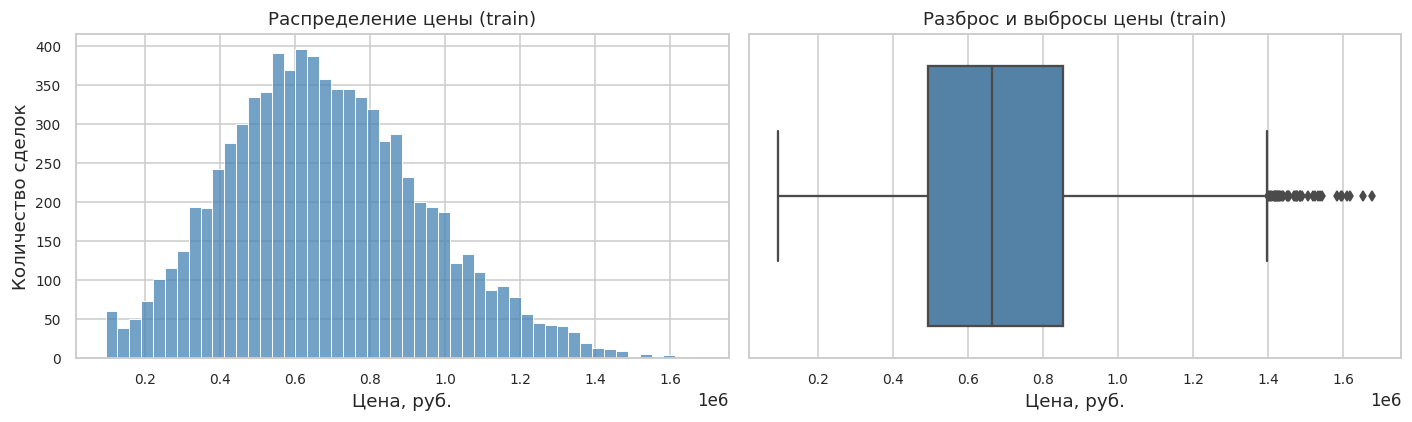

In [5]:
target_stats = pd.DataFrame({
    'train': train_full[TARGET].describe(),
    'test': test[TARGET].describe(),
}).round(0)
target_stats.loc['skew'] = [train_full[TARGET].skew().round(3), test[TARGET].skew().round(3)]
target_stats.columns.name = 'price_rub, руб.'
display(target_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train_full[TARGET], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение цены (train)')
axes[0].set_xlabel('Цена, руб.')
axes[0].set_ylabel('Количество сделок')
sns.boxplot(x=train_full[TARGET], ax=axes[1], color='steelblue')
axes[1].set_title('Разброс и выбросы цены (train)')
axes[1].set_xlabel('Цена, руб.')
for ax in axes:
    ax.tick_params(labelsize=9)
fig.tight_layout()
plt.show()

### Вывод: целевая переменная

* Цена сделки лежит в диапазоне **от 95 000 до 1 676 525 руб.**, медиана - **663 866 руб.**,
  среднее - 683 648 руб.
* Распределение **почти симметрично**: коэффициент асимметрии 0.34 на обучающей выборке и
  0.41 на тестовой, среднее выше медианы всего на 3%. Логарифмировать цель не нужно.
* За верхним усом боксплота **45 наблюдений (0.56% выборки)**, ниже нижнего уса нет ни одного.
  Это не аномалии, а естественный премиум-хвост: максимум 1.68 млн руб. - правдоподобная цена
  автомобиля, удалять такие сделки нельзя.
* Обучающая и тестовая выборки **однородны**: медианы 663 866 и 649 284 руб. (разница 2.2%),
  стандартные отклонения 264 923 и 268 020 руб.

**Итог:** цель не требует преобразований, а тест представителен - метрики финальной проверки
можно будет сравнивать с валидацией напрямую.

### Числовые признаки и корреляции

Числовые признаки обучающей выборки,count,mean,std,min,25%,50%,75%,max
make_year,8000.0,2009.22,8.39,1995.0,2002.00,2009.00,2017.00,2023.0
mileage_kmpl,8000.0,17.95,5.02,5.0,14.53,17.97,21.35,35.0
engine_cc,8000.0,2289.69,1289.81,800.0,1200.00,2000.00,3000.00,5000.0
owner_count,8000.0,3.00,1.42,1.0,2.00,3.00,4.00,5.0
accidents_reported,8000.0,0.49,0.69,0.0,0.00,0.00,1.00,5.0
price_rub,8000.0,683647.87,264923.50,95000.0,493857.00,663866.00,855056.00,1676525.0


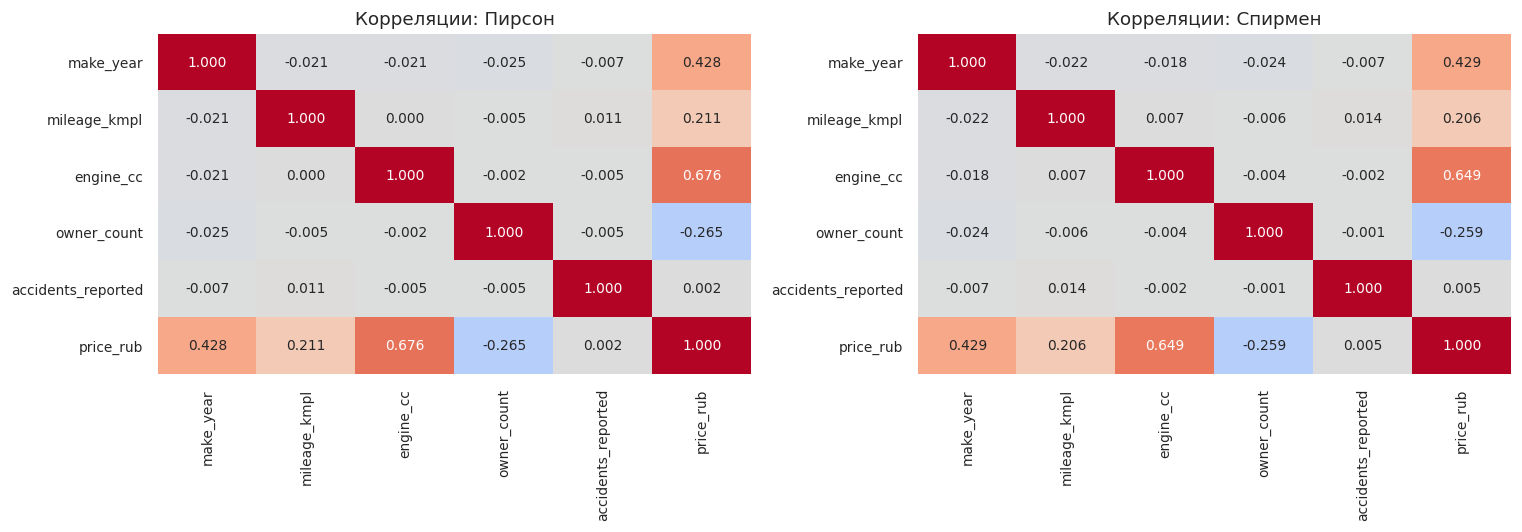

In [6]:
numeric_stats = train_full[NUM_FEATURES + [TARGET]].describe().T.round(2)
numeric_stats.columns.name = 'Числовые признаки обучающей выборки'
display(numeric_stats)

pearson = train_full[NUM_FEATURES + [TARGET]].corr()
spearman = train_full[NUM_FEATURES + [TARGET]].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, matrix, name in zip(axes, (pearson, spearman), ('Пирсон', 'Спирмен')):
    sns.heatmap(matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, ax=ax, cbar=False, annot_kws={'size': 9})
    ax.set_title(f'Корреляции: {name}')
    ax.tick_params(labelsize=9)
fig.tight_layout()
plt.show()

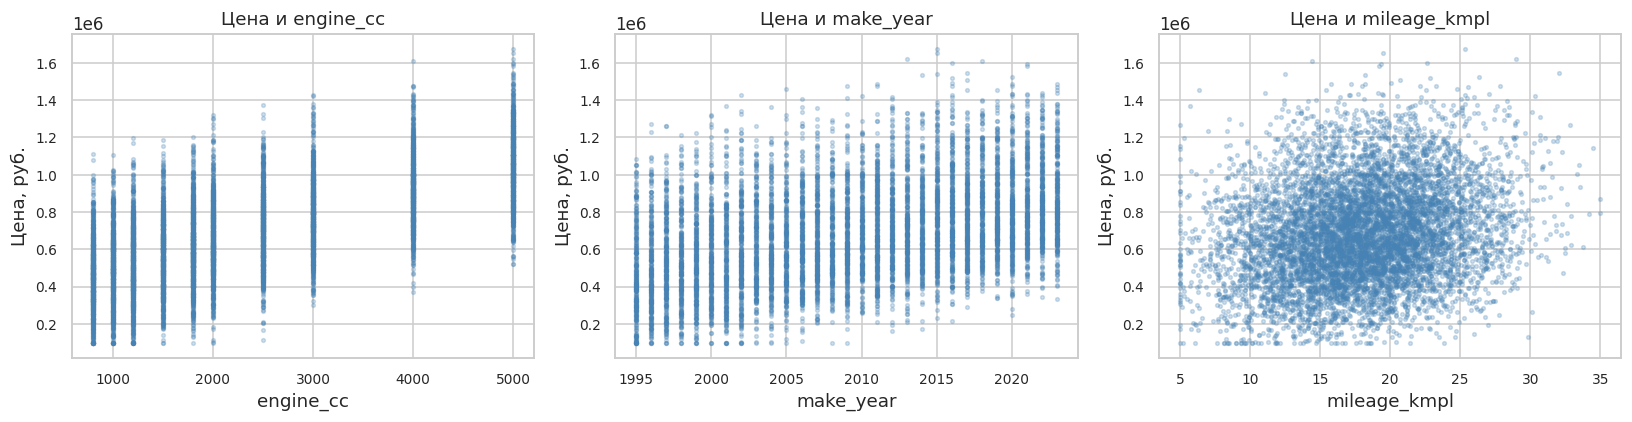

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature in zip(axes, ['engine_cc', 'make_year', 'mileage_kmpl']):
    ax.scatter(train_full[feature], train_full[TARGET], s=6, alpha=0.25, color='steelblue')
    ax.set_title(f'Цена и {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Цена, руб.')
    ax.tick_params(labelsize=9)
fig.tight_layout()
plt.show()

### Вывод: числовые признаки

* Сильнее всего с ценой связан **объём двигателя**: корреляция Пирсона **0.676**. Медианная
  цена растёт монотонно с 461 724 руб. при 800 см³ до 1 051 028 руб. при 5 000 см³, то есть
  в 2.3 раза.
* **Год выпуска** - второй фактор (**0.428**): медиана поднимается с 498 319 руб. у машин
  1995-2000 годов до 790 825 руб. у машин 2016-2023 годов, разница 58.7%.
* **Количество владельцев** работает в минус (**-0.265**): 758 554 руб. у первого владельца
  против 561 508 руб. у пятого, то есть -26%.
* **`mileage_kmpl` ведёт себя не как пробег.** В описании данных это «пробег в км», но значения
  лежат в диапазоне 5-35 при среднем 17.9, а корреляция с ценой **положительная** (+0.211).
  Так выглядит расход топлива в километрах на литр: экономичная машина стоит дороже. Для
  дерева решений это не проблема - признак используется как есть, - но название столбца стоит
  уточнить у поставщика данных, иначе в интерфейсе приложения оно введёт пользователя
  в заблуждение.
* **Число ДТП на цену не влияет**: корреляция **0.002**, медианы групп с 0, 1 и 2 авариями
  различаются меньше чем на 1% (663 068, 665 764 и 667 827 руб.). Это прямо расходится с
  описанием данных, где `accidents_reported` назван фактором, который «сильно бьёт по цене».
* Мультиколлинеарности нет: максимальная корреляция между парой признаков - **0.025**.

**Итог:** цену в этих данных определяют техника (объём двигателя, возраст) и история
владения, а заявленный фактор аварийности себя не проявляет.

### Категориальные признаки

In [8]:
def category_profile(df, column):
    """Размер категории и уровень цены внутри неё."""
    profile = df.groupby(column)[TARGET].agg(['size', 'median', 'mean']).round(0)
    profile.columns = ['сделок', 'медианная цена', 'средняя цена']
    profile['отклонение медианы от общей, %'] = (
        (profile['медианная цена'] / df[TARGET].median() - 1) * 100
    ).round(1)
    return profile.sort_values('медианная цена', ascending=False)


for column in ['fuel_type', 'brand', 'region']:
    profile = category_profile(train_full, column)
    profile.columns.name = column
    display(profile)

fuel_type,сделок,медианная цена,средняя цена,"отклонение медианы от общей, %"
fuel_type,,,,
Electric,797,912343.0,928178.0,37.4
Diesel,3213,645799.0,657954.0,-2.7
Petrol,3990,635570.0,655494.0,-4.3


brand,сделок,медианная цена,средняя цена,"отклонение медианы от общей, %"
brand,,,,
BMW,827,678124.0,692037.0,2.1
Ford,742,678090.0,699378.0,2.1
Honda,804,676352.0,690464.0,1.9
Nissan,870,668361.0,675254.0,0.7
Volkswagen,831,666482.0,687766.0,0.4
Toyota,792,663090.0,675791.0,-0.1
Chevrolet,800,661910.0,691261.0,-0.3
Kia,765,654129.0,677658.0,-1.5
Tesla,784,650532.0,672272.0,-2.0


region,сделок,медианная цена,средняя цена,"отклонение медианы от общей, %"
region,,,,
Юг,1408,669221,689466.0,0.8
СПб,1346,667138,686690.0,0.5
Урал,1371,665710,685679.0,0.3
Дальний Восток,1295,663348,679099.0,-0.1
Москва,1319,659440,675014.0,-0.7
Сибирь,1261,658250,685399.0,-0.8


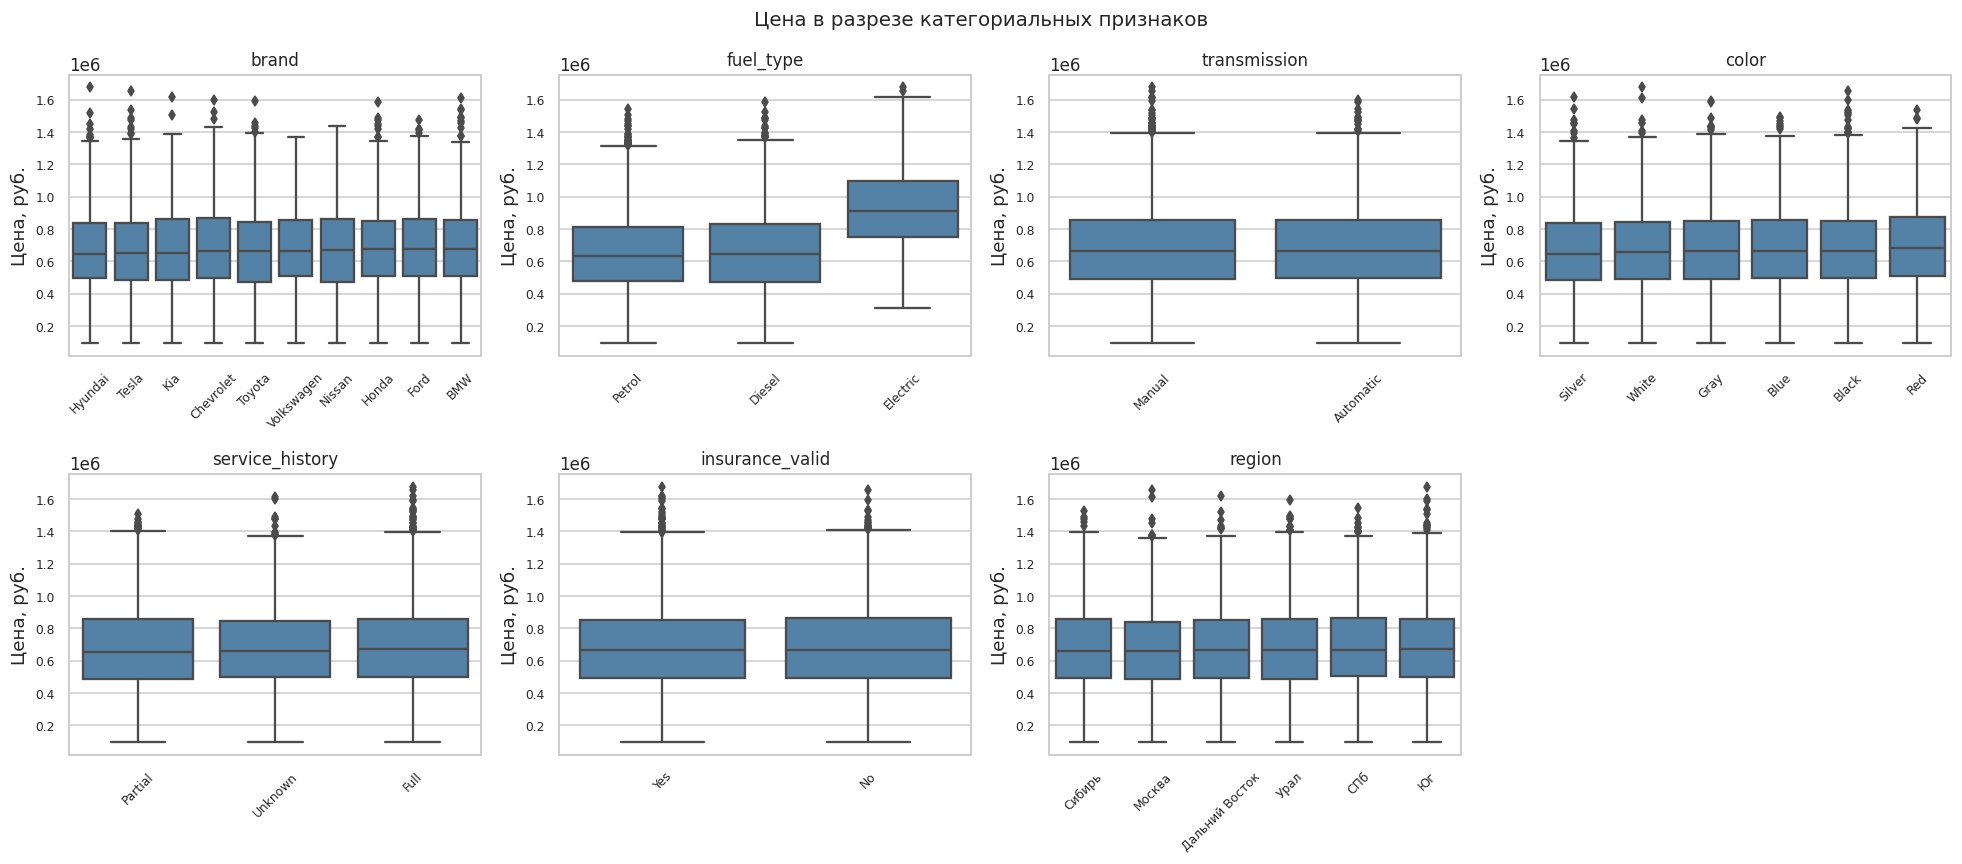

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, column in zip(axes.ravel(), CAT_FEATURES):
    order = train_full.groupby(column)[TARGET].median().sort_values().index
    sns.boxplot(data=train_full, x=column, y=TARGET, order=order, ax=ax, color='steelblue')
    ax.set_title(column, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Цена, руб.')
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
axes.ravel()[-1].axis('off')
fig.suptitle('Цена в разрезе категориальных признаков', fontsize=13)
fig.tight_layout()
plt.show()

In [10]:
category_spread = pd.DataFrame([
    {
        'признак': column,
        'категорий': train_full[column].nunique(),
        'мин. медиана': train_full.groupby(column)[TARGET].median().min(),
        'макс. медиана': train_full.groupby(column)[TARGET].median().max(),
        'размах медиан, %': round(
            (train_full.groupby(column)[TARGET].median().max()
             / train_full.groupby(column)[TARGET].median().min() - 1) * 100, 1),
    }
    for column in CAT_FEATURES
]).set_index('признак').sort_values('размах медиан, %', ascending=False)
category_spread.columns.name = 'Насколько категории признака разводят цену'
display(category_spread)

Насколько категории признака разводят цену,категорий,мин. медиана,макс. медиана,"размах медиан, %"
признак,,,,
fuel_type,3,635569.5,912343.0,43.5
color,6,644876.0,686239.0,6.4
brand,10,648065.0,678124.0,4.6
service_history,3,656332.0,669686.0,2.0
region,6,658250.0,669221.0,1.7
insurance_valid,2,662980.0,667235.5,0.6
transmission,2,662782.0,666395.0,0.5


### Вывод: категориальные признаки

* Крупный эффект даёт только **тип топлива**: медиана электромобилей **912 343 руб.** против
  635 570 руб. у бензиновых, размах медиан внутри признака - **43.5%**. Электромобили дороже
  остального парка на 42.5% по медиане.
* У остальных шести признаков размах медиан **не превышает 6.4%**: `color` 6.4%, `brand` 4.6%,
  `service_history` 2.0%, `region` 1.7%, `insurance_valid` 0.6%, `transmission` 0.5%.
* **Марка почти не разводит цену**: между самой дорогой (BMW, 678 124 руб.) и самой дешёвой
  (Hyundai, 648 065 руб.) всего 4.6%. Это расходится с описанием данных, где марка названа
  «фундаментом цены: престиж и надёжность бренда».
* **Регионы практически не различаются**: 1.7% между Югом (669 221) и Сибирью (658 250),
  хотя бизнес ожидает выраженную региональную специфику цен.
* Категории сбалансированы: минимальная группа - 742 сделки (Ford), максимальная - 3 990
  (Petrol). Редких категорий, которые пришлось бы объединять, нет.

**Итог:** из семи категориальных признаков предсказательную силу несёт по сути один -
`fuel_type`; остальные будут работать как слабые поправки.

## Выводы по разделу EDA

1. **Данные готовы к моделированию.** 8 000 обучающих и 2 000 тестовых сделок, ни одного
   пропуска, ни одного дубликата, типы прочитаны корректно.
2. **Целевая переменная удобна для MAE-регрессии.** Распределение почти симметрично
   (асимметрия 0.34), тяжёлого хвоста нет, 45 дорогих сделок за усом боксплота - реальный
   премиум-сегмент, а не мусор.
3. **Сигнал сосредоточен в четырёх признаках:** `engine_cc` (корреляция 0.676),
   `make_year` (0.428), `owner_count` (-0.265), `fuel_type` (разрыв медиан 43.5%).
   Пятым идёт `mileage_kmpl` (0.211).
4. **Три расхождения с описанием данных, о которых нужно сказать заказчику:**
   * `accidents_reported` не влияет на цену (корреляция 0.002), хотя заявлен как сильный фактор;
   * `brand` разводит медианы всего на 4.6%, хотя назван «фундаментом цены»;
   * `mileage_kmpl` по значениям и знаку корреляции похож на расход топлива, а не на пробег.
5. **Обучающая и тестовая выборки однородны** по цене и по составу категорий, новых категорий
   в тесте нет.

**Итоговая мысль.** Потолок качества в этой задаче задают четыре-пять признаков, а не богатство
описания автомобиля. Ожидать от бустинга R² существенно выше 0.85 не стоит: остальные признаки
почти не несут информации о цене.

# **Часть 2. Предобработка**

На этом этапе подготовьте данные для честного соревнования библиотек. Помните: качество входных данных определяет предел точности самого мощного алгоритма.

**Задание 2.1:**

* Создайте одинаковые обучающие и валидационные наборы данных для всех трех библиотек.
* Подготовьте признаки для каждой библиотеки.
* Зафиксируйте тест: используйте файл `ds_s16_test_data.csv` как отложенную тестовую выборку.

## 2.1. Разбиение выборок

Схема разбиения одна на все три библиотеки:

* `ds_s16_train_data.csv` делится на **обучающую** (80%) и **валидационную** (20%) части с
  `random_state=42`. На валидации сравниваем библиотеки и подбираем гиперпараметры.
* `ds_s16_test_data.csv` целиком становится **отложенным тестом** и до части 6 не используется.

Одинаковые строки во всех трёх экспериментах - обязательное условие честного турнира: иначе
разница в метриках объяснялась бы разным разбиением, а не качеством алгоритмов.

In [11]:
X_full = train_full[FEATURES]
y_full = train_full[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=VAL_SIZE, random_state=RANDOM_STATE
)
X_test, y_test = test[FEATURES], test[TARGET]

split_report = pd.DataFrame([
    {'выборка': 'обучающая', 'строк': len(X_train),
     'доля от train-файла': round(len(X_train) / len(X_full), 2),
     'медианная цена': y_train.median(), 'средняя цена': round(y_train.mean(), 0)},
    {'выборка': 'валидационная', 'строк': len(X_val),
     'доля от train-файла': round(len(X_val) / len(X_full), 2),
     'медианная цена': y_val.median(), 'средняя цена': round(y_val.mean(), 0)},
    {'выборка': 'тестовая (отложенная)', 'строк': len(X_test),
     'доля от train-файла': np.nan,
     'медианная цена': y_test.median(), 'средняя цена': round(y_test.mean(), 0)},
]).set_index('выборка')
split_report.columns.name = 'Разбиение данных'
display(split_report)

assert not set(X_train.index) & set(X_val.index), 'train и validation пересекаются'
assert len(X_train) + len(X_val) == len(X_full), 'при разбиении потеряны строки'

Разбиение данных,строк,доля от train-файла,медианная цена,средняя цена
выборка,,,,
обучающая,6400,0.8,662700.5,683363.0
валидационная,1600,0.2,668214.5,684786.0
тестовая (отложенная),2000,NaN,649284.0,675792.0


## 2.2. Кодирование признаков

Пропусков в данных нет, масштабирование деревьям не нужно, поэтому предобработка сводится к
кодированию семи категориальных признаков. Формат у библиотек разный, но информация в нём одна
и та же:

* **XGBoost и LightGBM** работают только с числами, поэтому категории кодируем
  `OneHotEncoder`. Кодировщик обучается **только на обучающей части** и затем применяется к
  валидации и тесту - это защита от утечки. `handle_unknown='ignore'` страхует от категории,
  которой не было в обучении.
* **CatBoost** принимает категории как есть через `cat_features` - это его штатный режим, и
  лишать библиотеку её сильной стороны означало бы заведомо испортить сравнение.

In [12]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False, dtype=np.float64)
encoder.fit(X_train[CAT_FEATURES])
OHE_COLUMNS = list(encoder.get_feature_names(CAT_FEATURES))


def to_ohe(df):
    """Числовые признаки без изменений плюс one-hot представление категорий."""
    coded = pd.DataFrame(
        encoder.transform(df[CAT_FEATURES]), columns=OHE_COLUMNS, index=df.index
    )
    return pd.concat([df[NUM_FEATURES], coded], axis=1)


X_train_ohe, X_val_ohe, X_test_ohe = to_ohe(X_train), to_ohe(X_val), to_ohe(X_test)

encoding_report = pd.DataFrame([
    {'формат': 'исходный (CatBoost)', 'всего признаков': X_train.shape[1],
     'числовых': len(NUM_FEATURES), 'категориальных': len(CAT_FEATURES)},
    {'формат': 'one-hot (XGBoost, LightGBM)', 'всего признаков': X_train_ohe.shape[1],
     'числовых': X_train_ohe.shape[1], 'категориальных': 0},
]).set_index('формат')
encoding_report.columns.name = 'Формат признаков по библиотекам'
display(encoding_report)

assert list(X_train_ohe.columns) == list(X_val_ohe.columns) == list(X_test_ohe.columns)
assert X_train_ohe.isna().sum().sum() == 0, 'после кодирования появились пропуски'

Формат признаков по библиотекам,всего признаков,числовых,категориальных
формат,,,
исходный (CatBoost),12,5,7
"one-hot (XGBoost, LightGBM)",37,37,0


### Вывод: подготовка данных

* Разбиение: **6 400 сделок в обучении, 1 600 в валидации, 2 000 в отложенном тесте**.
  Медианные цены частей - 662 700, 668 215 и 649 284 руб., то есть выборки сопоставимы и
  сравнение библиотек не будет искажено разбиением.
* `assert` подтверждают, что train и validation не пересекаются и ни одна строка не потеряна.
* One-hot кодирование превращает 12 признаков в **37**; CatBoost работает с исходными 12.
  Информация одна и та же, различается только формат.
* Кодировщик обучен **только на обучающей части**, пропусков после преобразования нет,
  порядок колонок в train, validation и test совпадает.

**Итог:** все три библиотеки получают одинаковые строки и одинаковую информацию - условия
турнира честные.


# **Часть 3. Обучение моделей в разных библиотеках**

Проверьте, как алгоритмы работают из коробки. Это покажет их естественную предрасположенность к вашему набору данных до начала тонкой настройки.

**Задание 3.1:**

* Обучите XGBoost, CatBoost и LightGBM на стандартных настройках.
* Установите для всех моделей `random_state=42`. В качестве целевой функции используйте MAE.
* Обучите каждую модель
* Задача со звёздочкой: замерьте время обучения и предсказания (Wall time) с помощью `%%time` или модуля `time`.

**Задание 3.2: Сравнение метрик**

* Рассчитайте математические метрики: MAE, RMSE, $R^2$.
* Рассчитайте бизнес-риски: Overpricing Rate (>20%) и Underpricing Loss (>20%).
* Сформулируйте гипотезу: какая библиотека на этом этапе кажется наиболее безопасной для бюджета компании?

**Задача со звёздочкой: модель с использованием Quantile Loss (квантильной регрессии) в CatBoost**

Что нужно сделать:

* Выберите библиотеку `CatBoost`. Реализуйте осторожную модель через квантильный лосс.
* Вместо стандартной функции потерь (MAE) установите `loss_function='Quantile'`.
* Настройте параметр квантиля. Достаточно при инициализации модели указать: `'Quantile:alpha=значение'`. Протестируйте разные значения, выберите оптимальное.
* Сравните результаты этой осторожной модели с базовой (обученной с помощью MAE):
  1. Насколько снизился Overpricing Rate?
  2. Насколько при этом вырос Underpricing Loss?
  3. Готовы ли вы рекомендовать такую безопасную модель Артёму (CEO) вместо самой точной базовой (обученной с помощью MAE)?

---

## 3.1. Метрики турнира

Базовые и бизнес-метрики считает одна функция, чтобы все модели оценивались одинаково.
Формулы бизнес-метрик взяты из описания проекта:

* `error_ratio = (прогноз - факт) / факт`;
* **Overpricing Rate** - доля наблюдений с `error_ratio > 0.20`;
* **Underpricing Loss** - сумма `факт - прогноз` по наблюдениям с `error_ratio < -0.20`.

Дополнительно считаем **Underpricing Rate** - долю занижений. Без неё Underpricing Loss нельзя
корректно сопоставить между моделями: сумма зависит и от частоты промахов, и от их размера.

In [13]:
def evaluate(y_true, y_pred):
    """Базовые и бизнес-метрики одним набором для любой модели."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    error_ratio = (y_pred - y_true) / y_true
    over_mask = error_ratio > RISK_LIMIT
    under_mask = error_ratio < -RISK_LIMIT
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': round(r2_score(y_true, y_pred), 6),
        'Overpricing Rate': over_mask.mean(),
        'Underpricing Rate': under_mask.mean(),
        'Underpricing Loss': (y_true[under_mask] - y_pred[under_mask]).sum(),
    }


def format_results(rows):
    """Единое оформление сводных таблиц с метриками."""
    table = pd.DataFrame(rows).set_index('модель')
    for column in ['MAE', 'RMSE', 'Underpricing Loss']:
        if column in table:
            table[column] = table[column].round(0)
    for column in ['Overpricing Rate', 'Underpricing Rate']:
        if column in table:
            table[column] = table[column].round(4)
    return table


def train_and_evaluate(name, model, X_fit, y_fit, X_eval, y_eval):
    """Обучение и оценка с замером wall time (задание со звёздочкой)."""
    start = time.time()
    model.fit(X_fit, y_fit)
    fit_seconds = time.time() - start

    start = time.time()
    predictions = np.asarray(model.predict(X_eval), dtype=float)
    predict_seconds = time.time() - start

    row = {'модель': name}
    row.update(evaluate(y_eval, predictions))
    row['время обучения, с'] = round(fit_seconds, 2)
    row['время предсказания, с'] = round(predict_seconds, 4)
    return model, predictions, row

## 3.2. Раунд 1: три библиотеки на настройках по умолчанию

Все три модели получают `random_state=42`, функцию потерь MAE и одинаковый бюджет потоков
(`N_JOBS = 4`). Остальные гиперпараметры - по умолчанию: задача раунда в том, чтобы увидеть
естественную предрасположенность каждой библиотеки к этим данным до тюнинга.

Дополнительно замеряем время обучения и предсказания (задание со звёздочкой): для мобильного
приложения задержка `predict` - это то, что напрямую почувствует пользователь.

Нижней планкой качества служит константный прогноз медианой обучающей выборки: модель, которая
его не бьёт, бесполезна.

In [14]:
def build_baselines():
    """Три модели раунда 1. Второй элемент кортежа - нужен ли модели one-hot формат."""
    return {
        'XGBoost': (
            XGBRegressor(objective='reg:absoluteerror', random_state=RANDOM_STATE,
                         n_jobs=N_JOBS),
            True,
        ),
        'LightGBM': (
            LGBMRegressor(objective='mae', random_state=RANDOM_STATE, n_jobs=N_JOBS),
            True,
        ),
        'CatBoost': (
            CatBoostRegressor(loss_function='MAE', random_seed=RANDOM_STATE,
                              thread_count=N_JOBS, verbose=0, cat_features=CAT_FEATURES),
            False,
        ),
    }


baseline_rows, baseline_models, baseline_preds = [], {}, {}
for name, (model, use_ohe) in build_baselines().items():
    X_fit, X_eval = (X_train_ohe, X_val_ohe) if use_ohe else (X_train, X_val)
    fitted, predictions, row = train_and_evaluate(name, model, X_fit, y_train, X_eval, y_val)
    baseline_models[name] = fitted
    baseline_preds[name] = predictions
    baseline_rows.append(row)

median_row = {'модель': 'Константа (медиана train)'}
median_row.update(evaluate(y_val, np.full(len(y_val), y_train.median())))
median_row['время обучения, с'] = 0.0
median_row['время предсказания, с'] = 0.0

baseline_results = format_results([median_row] + baseline_rows)
baseline_results.columns.name = 'Раунд 1: настройки по умолчанию, валидация'
display(baseline_results)

default_settings = pd.DataFrame([
    # sklearn-обёртка XGBoost хранит незаданные параметры как None, поэтому
    # подставляем документированные значения по умолчанию самой библиотеки
    {'библиотека': 'XGBoost',
     'деревьев по умолчанию': baseline_models['XGBoost'].n_estimators or 100,
     'глубина по умолчанию': baseline_models['XGBoost'].max_depth or 6},
    {'библиотека': 'LightGBM', 'деревьев по умолчанию': baseline_models['LightGBM'].n_estimators,
     'глубина по умолчанию': baseline_models['LightGBM'].max_depth},
    {'библиотека': 'CatBoost',
     'деревьев по умолчанию': baseline_models['CatBoost'].tree_count_,
     'глубина по умолчанию': baseline_models['CatBoost'].get_param('depth') or 6},
]).set_index('библиотека')
default_settings.columns.name = 'Что означают "настройки по умолчанию"'
display(default_settings)

"Раунд 1: настройки по умолчанию, валидация",MAE,RMSE,R2,Overpricing Rate,Underpricing Rate,Underpricing Loss,"время обучения, с","время предсказания, с"
модель,,,,,,,,
Константа (медиана train),206847.0,261177.0,-0.007202,0.3181,0.2750,153432589.0,0.00,0.0000
XGBoost,85438.0,107096.0,0.830647,0.1469,0.0819,23075764.0,0.17,0.0097
LightGBM,81752.0,102273.0,0.845556,0.1388,0.0706,18885599.0,0.07,0.0058
CatBoost,79509.0,99257.0,0.854531,0.1331,0.0662,17151898.0,4.03,0.0065


"Что означают ""настройки по умолчанию""",деревьев по умолчанию,глубина по умолчанию
библиотека,,
XGBoost,100,6
LightGBM,100,-1
CatBoost,1000,6


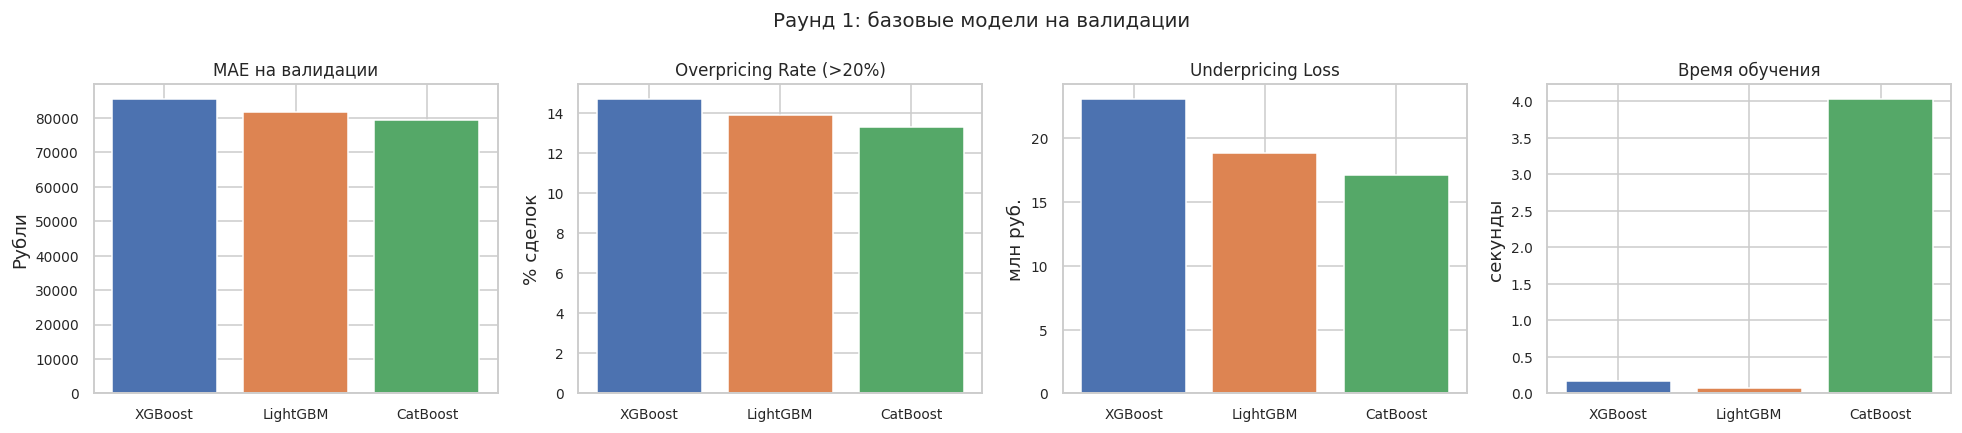

In [15]:
library_names = list(baseline_preds)
palette = dict(zip(library_names, sns.color_palette('deep', len(library_names))))
metrics_plot = baseline_results.drop(index='Константа (медиана train)')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
panels = [
    ('MAE', metrics_plot['MAE'], 'Рубли', 'MAE на валидации'),
    ('Overpricing Rate', metrics_plot['Overpricing Rate'] * 100, '% сделок',
     'Overpricing Rate (>20%)'),
    ('Underpricing Loss', metrics_plot['Underpricing Loss'] / 1e6, 'млн руб.',
     'Underpricing Loss'),
    ('время обучения, с', metrics_plot['время обучения, с'], 'секунды', 'Время обучения'),
]
for ax, (_, values, ylabel, title) in zip(axes, panels):
    ax.bar(values.index, values.values, color=[palette[name] for name in values.index])
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(labelsize=9)
fig.suptitle('Раунд 1: базовые модели на валидации', fontsize=13)
fig.tight_layout()
plt.show()

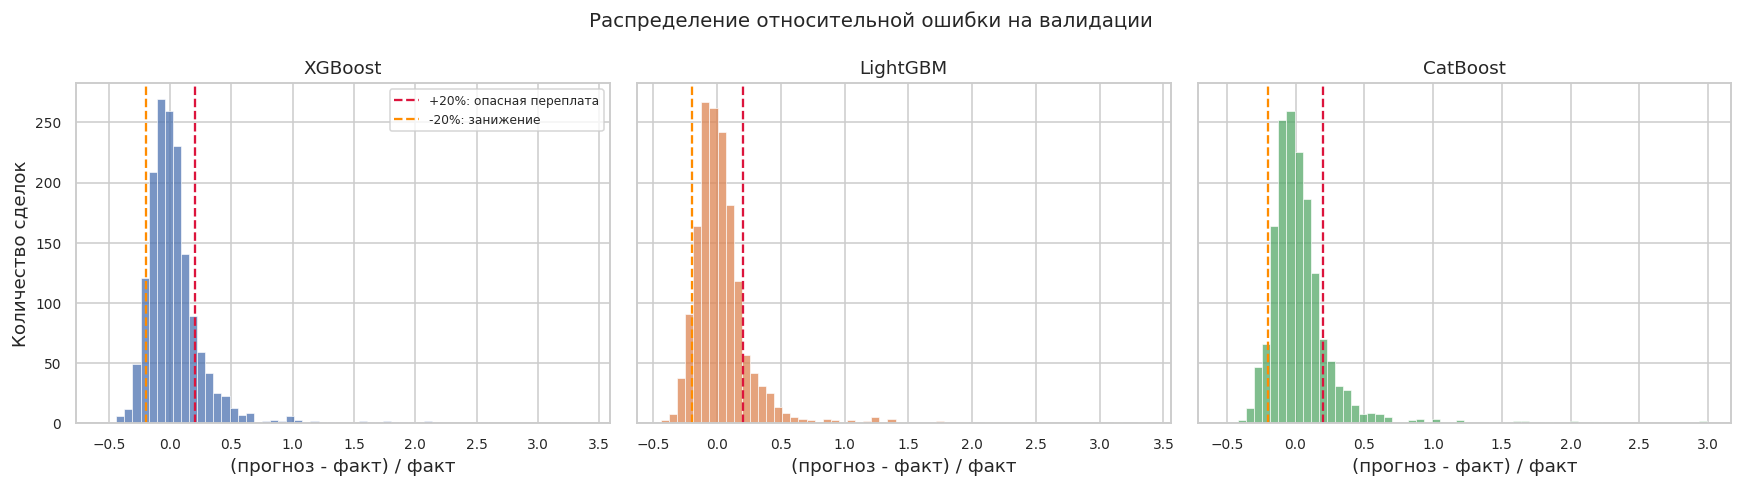

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, name in zip(axes, library_names):
    errors = (baseline_preds[name] - y_val.values) / y_val.values
    sns.histplot(errors, bins=60, ax=ax, color=palette[name])
    ax.axvline(RISK_LIMIT, color='crimson', linestyle='--', label='+20%: опасная переплата')
    ax.axvline(-RISK_LIMIT, color='darkorange', linestyle='--', label='-20%: занижение')
    ax.set_title(name)
    ax.set_xlabel('(прогноз - факт) / факт')
    ax.set_ylabel('Количество сделок')
    ax.tick_params(labelsize=9)
axes[0].legend(fontsize=8)
fig.suptitle('Распределение относительной ошибки на валидации', fontsize=13)
fig.tight_layout()
plt.show()

### Вывод: раунд 1 на настройках по умолчанию

**Все три библиотеки уверенно бьют константу.** Прогноз медианой даёт MAE 206 847 руб. и
R² около нуля; худшая из моделей ошибается в 2.4 раза меньше, лучшая - в 2.6 раза.

**Порядок на этих данных:**

| Место | Библиотека | MAE, руб. | R² | Overpricing Rate | Underpricing Loss |
|---|---|---|---|---|---|
| 1 | CatBoost | 79 509 | 0.855 | 13.31% | 17.15 млн руб. |
| 2 | LightGBM | 81 752 | 0.846 | 13.88% | 18.89 млн руб. |
| 3 | XGBoost | 85 438 | 0.831 | 14.69% | 23.08 млн руб. |

* **Ранжирование по бизнес-метрикам совпадает с ранжированием по MAE.** Это не обязано было
  случиться: модель может быть точной в среднем и при этом чаще срываться в опасное завышение.
  Здесь такого расхождения нет, поэтому дальше можно ориентироваться на MAE как на основной
  критерий, проверяя бизнес-метрики контрольно.
* Разрыв между лучшей и худшей моделью - **5 929 руб. MAE (7.5%)** и **5.93 млн руб.**
  упущенной выгоды на 1 600 сделках.

**Время работы (задание со звёздочкой).** Обучение: LightGBM **0.07 с**, XGBoost **0.17 с**,
CatBoost **4.03 с** - в 24-58 раз дольше конкурентов. Причину видно в таблице настроек по
умолчанию: CatBoost из коробки строит **1 000 деревьев** против 100 у XGBoost и LightGBM,
то есть сравниваются не столько алгоритмы, сколько их дефолтные бюджеты. Предсказание у всех
трёх занимает **0.006-0.010 с на 1 600 автомобилей**, то есть 4-6 микросекунд на объект:
задержка приложения будет определяться сетью, а не моделью.

**Гипотеза для бизнеса.** Самой безопасной для бюджета на этом этапе выглядит **CatBoost**:
при лучшей точности он даёт и наименьшую долю опасных переплат (13.31% против 14.69% у
XGBoost), и наименьшую упущенную выгоду. Проверим, сохранится ли преимущество после тюнинга.

## 3.3. Задача со звёздочкой: осторожная модель на квантильном лоссе

Модель с MAE целится в медиану и одинаково штрафует промах вверх и вниз. Квантильный лосс
позволяет сместить прицел: при `alpha < 0.5` завышение штрафуется сильнее занижения, модель
начинает называть цену осторожнее и доля опасных переплат падает ценой роста упущенной выгоды.

Перебираем `alpha` в цикле от 0.5 (эквивалент MAE) до 0.2 на CatBoost с настройками по
умолчанию, чтобы разница объяснялась только функцией потерь.

In [17]:
QUANTILE_ALPHAS = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2]

quantile_rows, quantile_preds = [], {}
for alpha in QUANTILE_ALPHAS:
    model = CatBoostRegressor(
        loss_function=f'Quantile:alpha={alpha}', random_seed=RANDOM_STATE,
        thread_count=N_JOBS, verbose=0, cat_features=CAT_FEATURES,
    )
    _, predictions, row = train_and_evaluate(
        f'CatBoost Quantile alpha={alpha}', model, X_train, y_train, X_val, y_val
    )
    quantile_preds[alpha] = predictions
    quantile_rows.append(row)

quantile_results = format_results(quantile_rows)
quantile_results.columns.name = 'Квантильная регрессия CatBoost, валидация'
display(quantile_results.drop(columns=['время обучения, с', 'время предсказания, с']))

"Квантильная регрессия CatBoost, валидация",MAE,RMSE,R2,Overpricing Rate,Underpricing Rate,Underpricing Loss
модель,,,,,,
CatBoost Quantile alpha=0.5,79509.0,99257.0,0.854531,0.1331,0.0662,17151898.0
CatBoost Quantile alpha=0.45,80668.0,100575.0,0.850643,0.1212,0.0831,22604509.0
CatBoost Quantile alpha=0.4,82553.0,102641.0,0.844443,0.1031,0.1056,29142709.0
CatBoost Quantile alpha=0.35,85311.0,105919.0,0.834348,0.0950,0.1306,36201639.0
CatBoost Quantile alpha=0.3,89634.0,111211.0,0.817383,0.0769,0.1662,46934679.0
CatBoost Quantile alpha=0.25,94953.0,117375.0,0.796578,0.0675,0.2150,60928421.0
CatBoost Quantile alpha=0.2,103583.0,126950.0,0.762036,0.0525,0.2762,80639517.0


Размен риска: выбран alpha=0.4,MAE,"рост MAE к alpha=0.5, %",Overpricing Rate,"снижение Overpricing, %","Underpricing Loss, млн руб.","рост Underpricing Loss, %",п.п. риска на 1 млн упущенной выгоды
alpha,,,,,,,
0.50,79509.0,0.0,0.1331,0.0,17.15,0.0,NaN
0.45,80668.0,1.5,0.1212,8.9,22.60,31.8,0.218
0.40,82553.0,3.8,0.1031,22.5,29.14,69.9,0.250
0.35,85311.0,7.3,0.0950,28.6,36.20,111.1,0.200
0.30,89634.0,12.7,0.0769,42.2,46.93,173.6,0.189
0.25,94953.0,19.4,0.0675,49.3,60.93,255.2,0.150
0.20,103583.0,30.3,0.0525,60.6,80.64,370.1,0.127


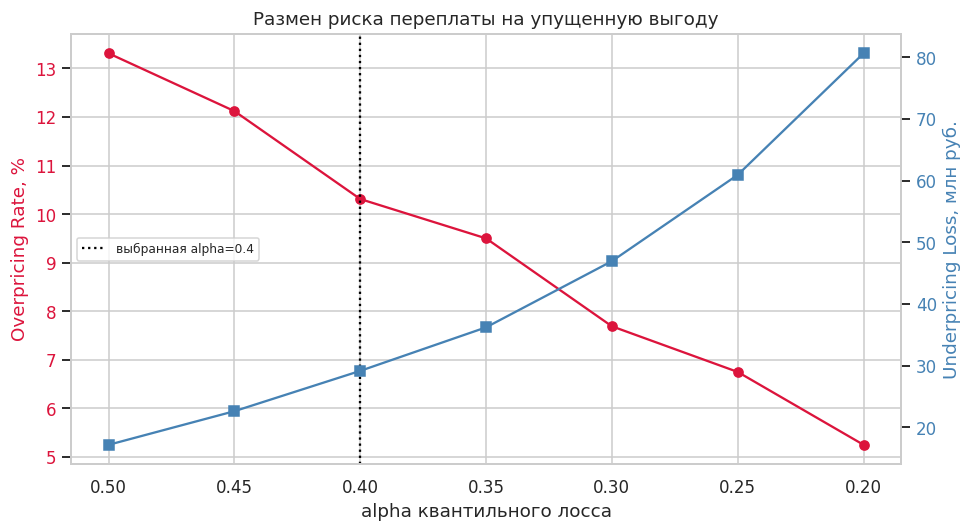

In [18]:
# Правило выбора alpha: сравниваем не абсолютный уровень риска, а эффективность размена -
# сколько процентных пунктов Overpricing Rate снимает каждый миллион рублей упущенной
# выгоды. Минимальная alpha всегда даёт минимальный Overpricing Rate, но платит за это
# непропорционально, поэтому выбор по одному лишь минимуму риска был бы бессмысленным.
base_over = quantile_results['Overpricing Rate'].values[0]
base_loss = quantile_results['Underpricing Loss'].values[0]
extra_loss_mln = (quantile_results['Underpricing Loss'].values - base_loss) / 1e6
saved_points = (base_over - quantile_results['Overpricing Rate'].values) * 100
efficiency = np.where(extra_loss_mln > 0, saved_points / np.where(extra_loss_mln > 0,
                                                                 extra_loss_mln, 1), np.nan)
BEST_ALPHA = QUANTILE_ALPHAS[int(np.nanargmax(efficiency))]
BEST_QUANTILE_NAME = f'CatBoost Quantile alpha={BEST_ALPHA}'

trade_off = pd.DataFrame({
    'alpha': QUANTILE_ALPHAS,
    'MAE': quantile_results['MAE'].values,
    'рост MAE к alpha=0.5, %': (
        (quantile_results['MAE'].values / quantile_results['MAE'].values[0] - 1) * 100).round(1),
    'Overpricing Rate': quantile_results['Overpricing Rate'].values,
    'снижение Overpricing, %': (
        (1 - quantile_results['Overpricing Rate'].values
         / quantile_results['Overpricing Rate'].values[0]) * 100).round(1),
    'Underpricing Loss, млн руб.': (quantile_results['Underpricing Loss'].values / 1e6).round(2),
    'рост Underpricing Loss, %': (
        (quantile_results['Underpricing Loss'].values
         / quantile_results['Underpricing Loss'].values[0] - 1) * 100).round(1),
    'п.п. риска на 1 млн упущенной выгоды': efficiency.round(3),
}).set_index('alpha')
trade_off.columns.name = f'Размен риска: выбран alpha={BEST_ALPHA}'
display(trade_off)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(QUANTILE_ALPHAS, quantile_results['Overpricing Rate'].values * 100,
        marker='o', color='crimson')
ax.axvline(BEST_ALPHA, color='black', linestyle=':', label=f'выбранная alpha={BEST_ALPHA}')
ax.set_xlabel('alpha квантильного лосса')
ax.set_ylabel('Overpricing Rate, %', color='crimson')
ax.tick_params(axis='y', labelcolor='crimson')
ax.invert_xaxis()

ax_right = ax.twinx()
ax_right.plot(QUANTILE_ALPHAS, quantile_results['Underpricing Loss'].values / 1e6,
              marker='s', color='steelblue')
ax_right.set_ylabel('Underpricing Loss, млн руб.', color='steelblue')
ax_right.tick_params(axis='y', labelcolor='steelblue')
ax_right.grid(False)

ax.set_title('Размен риска переплаты на упущенную выгоду')
ax.legend(fontsize=8, loc='center left')
fig.tight_layout()
plt.show()

### Вывод: стоит ли делать модель осторожной

**Размен работает ровно так, как обещает теория.** По мере снижения `alpha` доля опасных
переплат падает с 13.31% до 5.25%, но упущенная выгода растёт с 17.15 до 80.64 млн руб.,
то есть в 4.7 раза, а MAE ухудшается на 30.3%.

**Крайний квантиль - плохая покупка.** Если выбирать по одному лишь минимуму риска, победил бы
`alpha = 0.2`, но каждый миллион рублей упущенной выгоды снимает там всего **0.127 п.п.**
риска переплаты. Лучшее соотношение у **`alpha = 0.4`: 0.250 п.п. на миллион**, то есть вдвое
эффективнее.

**Что даёт `alpha = 0.4` относительно обычной MAE-модели:**

1. **Overpricing Rate снизился с 13.31% до 10.31%** - на 3.0 процентных пункта, или на 22.5%
   в относительном выражении.
2. **Underpricing Loss вырос с 17.15 до 29.14 млн руб.** - на 11.99 млн, или на 69.9%. MAE при
   этом ухудшился всего на 3.8% (79 509 → 82 553 руб.).
3. **Готов ли я рекомендовать эту модель Артёму вместо базовой?** Как единственную - нет.
   Каждый процентный пункт снятого риска переплаты обходится в 4 млн руб. упущенной выгоды,
   а на 1 600 сделках валидации это размен 48 предотвращённых переплат на 12 млн руб.
   недополученной выручки. Стартапу, который растёт за счёт потока сделок, такой обмен
   невыгоден.

**Итоговая мысль.** Квантильную модель стоит держать не вместо основной, а **как отдельный
осторожный режим** - например, для сегментов, где модель систематически ошибается вверх, или
на период, когда у компании ограничен оборотный капитал и переплата опаснее упущенной сделки.
Переключение между режимами не требует переобучения: это одна и та же библиотека с другой
функцией потерь.

# **Часть 4. Работа с параметрами модели (Тюнинг)**

Теперь ваша задача — заставить алгоритмы работать на пределе возможностей, подбирая ключи к их гиперпараметрам. Чтобы сравнение было объективным, используйте единую стратегию поиска для всех библиотек.

**Задание 4.1:**

* Настройте поиск в Optuna для каждой модели.
* Использьзуйте сетку параметров, предложенную в описании проекта:
  1. **Общая сетка для всех моделей:**
    * Скорость обучения (`learning_rate/eta`): от `0.01` до `0.1, log=True`.
    * Глубина дерева (`max_depth/depth`): от `3` до `10`.
    * Количество итераций (`n_estimators/iterations`): зафиксируйте в диапазоне `500–2000`.
  2. **Специфические параметры (регуляризация):**
  * Для XGBoost: добавьте параметры `gamma` (от `1e-8` до `1.0`) и `reg_lambda/reg_alpha`(от `1e-8` до `10.0`).
  * Для CatBoost: используйте `l2_leaf_reg` (от `1` до `10`).
  * Для LightGBM: добавьте `num_leaves` (от `20` до `256`) и `min_child_samples` (от `5` до `100`); `reg_alpha` и `reg_lambda` от `1e-8` до `1.0`.
  3. Не забудьте `"random_seed": 42` и `MAE` .

* Проведите поиск гиперпараметров с помощью Optuna.
---


## 4.1. Единая стратегия поиска

Сетка параметров задана в описании проекта и одинакова по смыслу для всех библиотек: скорость
обучения, глубина дерева, число итераций плюс специфическая регуляризация. Условия поиска тоже
общие:

* оптимизируемая величина - **MAE на валидационной выборке** (та же метрика, что и функция потерь);
* `TPESampler(seed=42)` - воспроизводимая последовательность испытаний;
* по 30 испытаний на библиотеку;
* тестовая выборка в поиске не участвует.

Названия параметров в Optuna общие (`learning_rate`, `n_estimators`, `depth`), а внутрь
библиотек они уходят под их собственными именами: `max_depth` у XGBoost и LightGBM,
`iterations` и `depth` у CatBoost. Так таблица лучших параметров читается построчно.

In [19]:
def suggest_params(trial, library):
    """Сетка из описания проекта: общая часть плюс регуляризация конкретной библиотеки."""
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    n_estimators = trial.suggest_int('n_estimators', 500, 2000)
    depth = trial.suggest_int('depth', 3, 10)

    if library == 'XGBoost':
        return {
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': depth,
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        }
    if library == 'LightGBM':
        return {
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': depth,
            'num_leaves': trial.suggest_int('num_leaves', 20, 256),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        }
    return {
        'learning_rate': learning_rate,
        'iterations': n_estimators,
        'depth': depth,
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
    }


def build_model(library, params):
    """Модель нужной библиотеки с функцией потерь MAE и зерном 42."""
    if library == 'XGBoost':
        return XGBRegressor(objective='reg:absoluteerror', random_state=RANDOM_STATE,
                            n_jobs=N_JOBS, **params)
    if library == 'LightGBM':
        return LGBMRegressor(objective='mae', random_state=RANDOM_STATE,
                             n_jobs=N_JOBS, **params)
    return CatBoostRegressor(loss_function='MAE', random_seed=RANDOM_STATE,
                             thread_count=N_JOBS, verbose=0,
                             cat_features=CAT_FEATURES, **params)


# XGBoost и LightGBM учатся на one-hot матрице, CatBoost - на исходных категориях
USES_OHE = {'XGBoost': True, 'LightGBM': True, 'CatBoost': False}


def features_for(library, ohe_version, raw_version):
    return ohe_version if USES_OHE[library] else raw_version


def make_objective(library):
    def objective(trial):
        model = build_model(library, suggest_params(trial, library))
        model.fit(features_for(library, X_train_ohe, X_train), y_train)
        predictions = model.predict(features_for(library, X_val_ohe, X_val))
        return mean_absolute_error(y_val, predictions)
    return objective

In [20]:
LIBRARIES = ['XGBoost', 'LightGBM', 'CatBoost']

studies, search_log = {}, []
for library in LIBRARIES:
    start = time.time()
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name=f'{library}_mae',
    )
    study.optimize(make_objective(library), n_trials=N_TRIALS, show_progress_bar=False)
    studies[library] = study
    search_log.append({'библиотека': library, 'испытаний': N_TRIALS,
                       'время поиска, с': round(time.time() - start, 0),
                       'лучший MAE': round(study.best_value, 0)})

search_report = pd.DataFrame(search_log).set_index('библиотека')
search_report.columns.name = 'Стоимость поиска гиперпараметров'
display(search_report)

Стоимость поиска гиперпараметров,испытаний,"время поиска, с",лучший MAE
библиотека,,,
XGBoost,30,52.0,80226.0
LightGBM,30,24.0,80360.0
CatBoost,30,242.0,79214.0


In [21]:
best_params_table = pd.DataFrame([
    {'библиотека': library,
     'лучший MAE (валидация)': round(study.best_value, 0),
     'номер лучшего испытания': study.best_trial.number,
     **{key: (round(value, 5) if isinstance(value, float) else value)
        for key, value in study.best_params.items()}}
    for library, study in studies.items()
]).set_index('библиотека')
best_params_table.columns.name = 'Лучшие гиперпараметры после Optuna'
display(best_params_table)

Лучшие гиперпараметры после Optuna,лучший MAE (валидация),номер лучшего испытания,learning_rate,n_estimators,depth,gamma,reg_lambda,reg_alpha,num_leaves,min_child_samples,l2_leaf_reg
библиотека,,,,,,,,,,,
XGBoost,80226.0,17,0.06827,1401,3,0.02009,0.00019,0.00000,NaN,NaN,NaN
LightGBM,80360.0,22,0.02703,1744,3,NaN,0.00000,0.03471,133.0,72.0,NaN
CatBoost,79214.0,11,0.03819,1587,3,NaN,NaN,NaN,NaN,NaN,9.79647


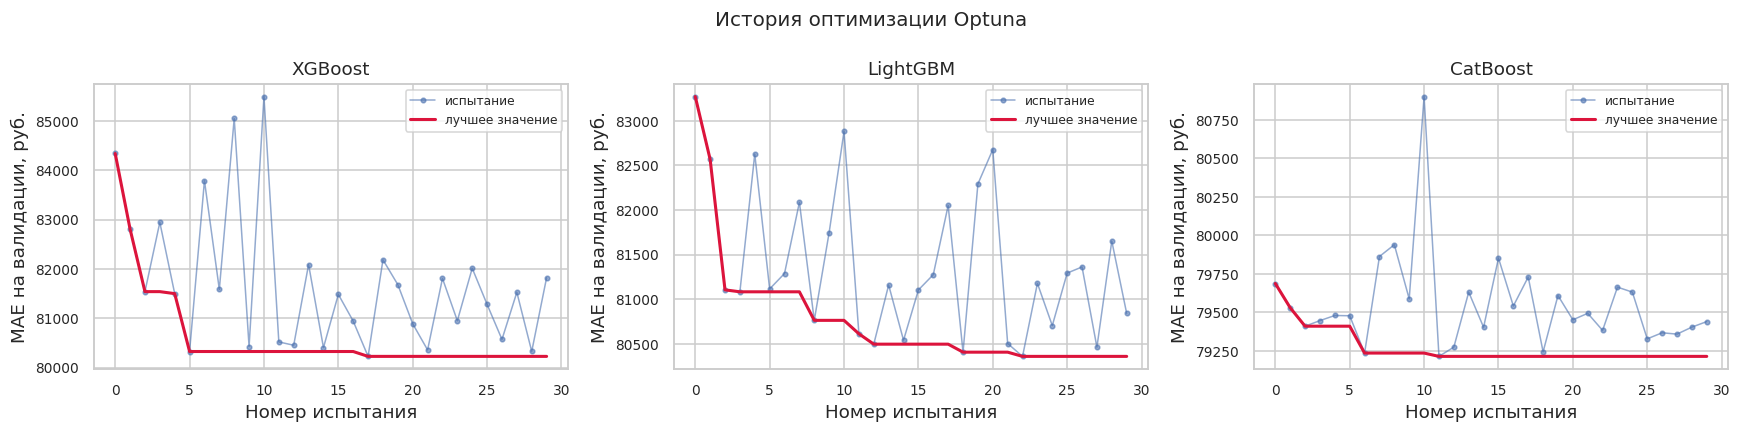

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, library in zip(axes, LIBRARIES):
    history = studies[library].trials_dataframe()[['number', 'value']]
    ax.plot(history['number'], history['value'], marker='o', markersize=3,
            linewidth=1, alpha=0.6, label='испытание')
    ax.plot(history['number'], history['value'].cummin(), color='crimson',
            linewidth=2, label='лучшее значение')
    ax.set_title(library)
    ax.set_xlabel('Номер испытания')
    ax.set_ylabel('MAE на валидации, руб.')
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8)
fig.suptitle('История оптимизации Optuna', fontsize=13)
fig.tight_layout()
plt.show()

## 4.2. Метрики оптимизированных моделей

Переобучаем каждую библиотеку с найденными параметрами и сравниваем результат с раундом 1.

In [23]:
tuned_rows, tuned_models, tuned_preds = [], {}, {}
for library in LIBRARIES:
    params = suggest_params(optuna.trial.FixedTrial(studies[library].best_params), library)
    fitted, predictions, row = train_and_evaluate(
        f'{library} (Optuna)', build_model(library, params),
        features_for(library, X_train_ohe, X_train), y_train,
        features_for(library, X_val_ohe, X_val), y_val,
    )
    tuned_models[library] = fitted
    tuned_preds[library] = predictions
    tuned_rows.append(row)

tuned_results = format_results(tuned_rows)
tuned_results.columns.name = 'Раунд 2: после Optuna, валидация'
display(tuned_results)

"Раунд 2: после Optuna, валидация",MAE,RMSE,R2,Overpricing Rate,Underpricing Rate,Underpricing Loss,"время обучения, с","время предсказания, с"
модель,,,,,,,,
XGBoost (Optuna),80226.0,100806.0,0.849957,0.1375,0.0719,19186743.0,2.02,0.0150
LightGBM (Optuna),80360.0,100822.0,0.849908,0.1356,0.0675,18205837.0,0.57,0.0366
CatBoost (Optuna),79214.0,98796.0,0.855881,0.1331,0.0638,16693871.0,5.46,0.0030


In [24]:
comparison = baseline_results.drop(index='Константа (медиана train)').copy()
comparison.index = [f'{name} (базовая)' for name in comparison.index]
comparison = pd.concat([comparison, tuned_results])

gain = pd.DataFrame([
    {
        'библиотека': library,
        'MAE базовая': baseline_results.loc[library, 'MAE'],
        'MAE после Optuna': tuned_results.loc[f'{library} (Optuna)', 'MAE'],
        'выигрыш MAE, %': round(
            (1 - tuned_results.loc[f'{library} (Optuna)', 'MAE']
             / baseline_results.loc[library, 'MAE']) * 100, 2),
        'Overpricing базовая': baseline_results.loc[library, 'Overpricing Rate'],
        'Overpricing после Optuna': tuned_results.loc[f'{library} (Optuna)', 'Overpricing Rate'],
        'время обучения базовой, с': baseline_results.loc[library, 'время обучения, с'],
        'время обучения после Optuna, с':
            tuned_results.loc[f'{library} (Optuna)', 'время обучения, с'],
    }
    for library in LIBRARIES
]).set_index('библиотека')
gain.columns.name = 'Что дал тюнинг'
display(gain)

comparison_sorted = comparison.sort_values('MAE')
comparison_sorted.columns.name = 'Все шесть моделей турнира на валидации'
display(comparison_sorted)

Что дал тюнинг,MAE базовая,MAE после Optuna,"выигрыш MAE, %",Overpricing базовая,Overpricing после Optuna,"время обучения базовой, с","время обучения после Optuna, с"
библиотека,,,,,,,
XGBoost,85438.0,80226.0,6.10,0.1469,0.1375,0.17,2.02
LightGBM,81752.0,80360.0,1.70,0.1388,0.1356,0.07,0.57
CatBoost,79509.0,79214.0,0.37,0.1331,0.1331,4.03,5.46


Все шесть моделей турнира на валидации,MAE,RMSE,R2,Overpricing Rate,Underpricing Rate,Underpricing Loss,"время обучения, с","время предсказания, с"
CatBoost (Optuna),79214.0,98796.0,0.855881,0.1331,0.0638,16693871.0,5.46,0.0030
CatBoost (базовая),79509.0,99257.0,0.854531,0.1331,0.0662,17151898.0,4.03,0.0065
XGBoost (Optuna),80226.0,100806.0,0.849957,0.1375,0.0719,19186743.0,2.02,0.0150
LightGBM (Optuna),80360.0,100822.0,0.849908,0.1356,0.0675,18205837.0,0.57,0.0366
LightGBM (базовая),81752.0,102273.0,0.845556,0.1388,0.0706,18885599.0,0.07,0.0058
XGBoost (базовая),85438.0,107096.0,0.830647,0.1469,0.0819,23075764.0,0.17,0.0097


### Вывод: что дал тюнинг

**Победитель не сменился, но разрыв сжался.**

| Библиотека | MAE базовая | MAE после Optuna | Выигрыш | Overpricing Rate после Optuna |
|---|---|---|---|---|
| CatBoost | 79 509 | **79 214** | 0.37% | 13.31% |
| XGBoost | 85 438 | 80 226 | **6.10%** | 13.75% |
| LightGBM | 81 752 | 80 360 | 1.70% | 13.56% |

* **Тюнинг выравнивает библиотеки.** До подбора параметров разброс MAE между тремя моделями
  составлял 7.5%, после - **1.4%**. Основную часть разрыва в раунде 1 объясняли не свойства
  алгоритмов, а разные настройки по умолчанию: XGBoost со 100 деревьями просто не успевал
  доучиться и выиграл от тюнинга больше всех.
* **Все три библиотеки независимо сошлись к `depth = 3`** - минимальной глубине из разрешённого
  диапазона 3-10. Это прямое подтверждение вывода EDA: зависимость цены от признаков простая,
  глубокие деревья начинают запоминать шум. Число деревьев при этом выбрано большим
  (1 401-1 744), то есть модели предпочитают много мелких коррекций с малым шагом
  (`learning_rate` 0.027-0.068).
* **Цена поиска сильно различается.** 30 испытаний заняли: LightGBM **24 с**, XGBoost **52 с**,
  CatBoost **242 с**. При переобучении модели раз в сутки это неважно, но при частых
  экспериментах CatBoost обходится в 10 раз дороже LightGBM по времени инженера.
* Бизнес-метрики после тюнинга улучшились у всех: Underpricing Loss у XGBoost упал с 23.08 до
  19.19 млн руб., у CatBoost - с 17.15 до 16.69 млн руб.

**Оговорка о честности оценки.** Гиперпараметры подбирались по MAE на валидации, поэтому
метрики валидации после тюнинга слегка оптимистичны: 30 испытаний подстраивались именно под эти
1 600 сделок. Величина этого смещения проверяется в части 6 на отложенном тесте, который в
поиске не участвовал.

**Итог:** лучшая модель турнира - **CatBoost (Optuna)** с MAE 79 214 руб., R² 0.8559 и
наименьшими бизнес-рисками. Преимущество над настроенным LightGBM невелико (1.4% MAE), и это
важно для решения о внедрении: если критична скорость обучения, LightGBM почти не уступает.

# **Часть 5. Интерпретация и бизнес-анализ**

Модель должна быть прозрачной. Ваша задача — убедиться, что алгоритм принимает решения на основе рыночных факторов, а не случайных корреляций.

**Задание 5.1:**

* Постройте SHAP Summary Plot для оптимизированных моделей после поиска Optuna.
* Проанализируйте:
  1. Какие Топ-5 признаков вносят наибольший вклад в цену автомобиля?
  2. Совпадают ли выводы модели с бизнес-логикой?
  3. Как специфические признаки (например, color или insurance_valid) влияют на предсказание?

**Задание 5.2**

Используйте введённые метрики Overpricing Rate и Underpricing Loss:
* Рассчитайте долю завышений и недооценок для каждой модели.
* Сравните модели не только по MAE и RMSE, но и по бизнес-рискам.

**Задание 5.3**

* Проанализируйте ошибки в разрезе категорий (марки автомобилей и макро-регионов).
* Выявите марки машин и регионы, где риск ошибки высок — это зоны, где в будущем потребуется ручная проверка экспертом.

---

## 5.1. Важность признаков через SHAP

SHAP раскладывает каждое предсказание на вклады признаков в рублях, поэтому его значения
читаются напрямую: «пробег снизил оценку этой машины на 40 тысяч». Считаем значения для трёх
оптимизированных моделей на подвыборке валидации.

У XGBoost и LightGBM признаки закодированы one-hot, поэтому вклад категориального признака
собираем обратно: суммируем средние модули вкладов всех его дамми-колонок. Без этого сравнение
с CatBoost, который работает с исходными категориями, было бы некорректным.

In [25]:
SHAP_SAMPLE = 1000
shap_index = X_val.sample(n=min(SHAP_SAMPLE, len(X_val)), random_state=RANDOM_STATE).index


def shap_values_for(library, model):
    """SHAP-значения и матрица признаков в том формате, в каком их ждёт библиотека."""
    if USES_OHE[library]:
        sample = X_val_ohe.loc[shap_index]
        return shap.TreeExplainer(model).shap_values(sample), sample
    sample = X_val.loc[shap_index]
    values = shap.TreeExplainer(model).shap_values(Pool(sample, cat_features=CAT_FEATURES))
    return values, sample


def to_numeric_display(sample):
    """Для beeswarm нужен числовой массив.

    Категории CatBoost заменяем кодами: цвет точки в этом случае показывает лишь номер
    категории и порядка в себе не несёт, поэтому у категориальных признаков смотрим
    только на размах вкладов по горизонтали.
    """
    frame = sample.copy()
    for column in frame.columns:
        if frame[column].dtype == object:
            frame[column] = pd.factorize(frame[column])[0]
    return frame


def collapse_to_source_features(values, columns):
    """Возврат от one-hot колонок к исходным признакам: сумма средних модулей вкладов."""
    importance = pd.Series(np.abs(values).mean(axis=0), index=columns)
    mapping = {}
    for column in columns:
        if column in FEATURES:
            # CatBoost работает с исходными признаками, сворачивать нечего
            mapping[column] = column
        else:
            mapping[column] = next(c for c in CAT_FEATURES if column.startswith(c + '_'))
    return importance.groupby(mapping).sum()


shap_data = {library: shap_values_for(library, tuned_models[library]) for library in LIBRARIES}
print('SHAP посчитан на', len(shap_index), 'объектах валидации')

SHAP посчитан на 1000 объектах валидации


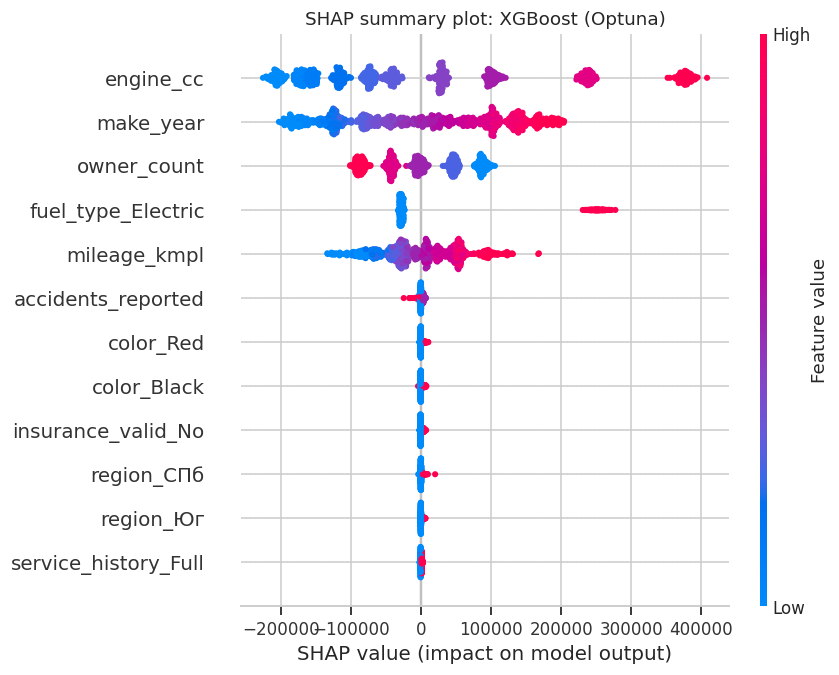

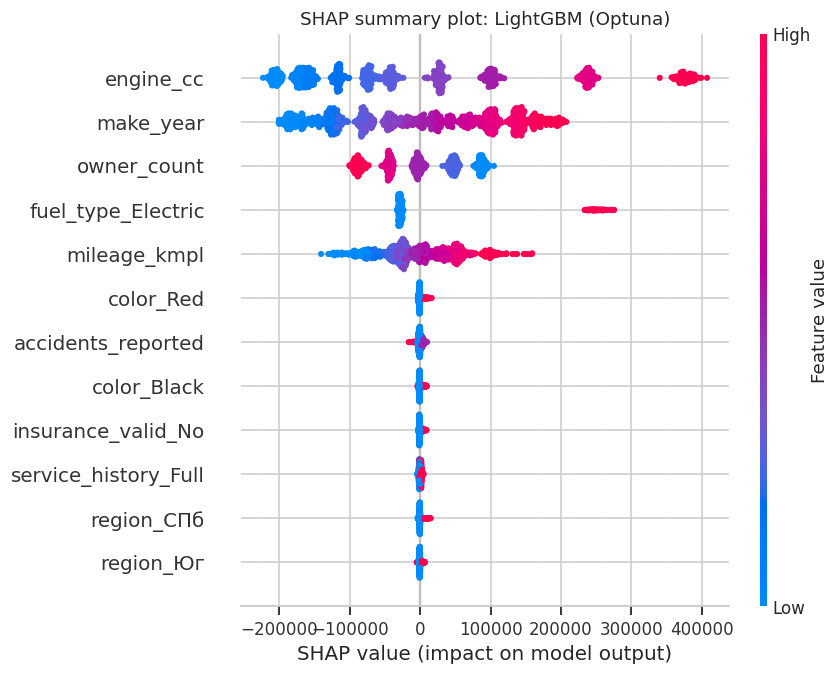

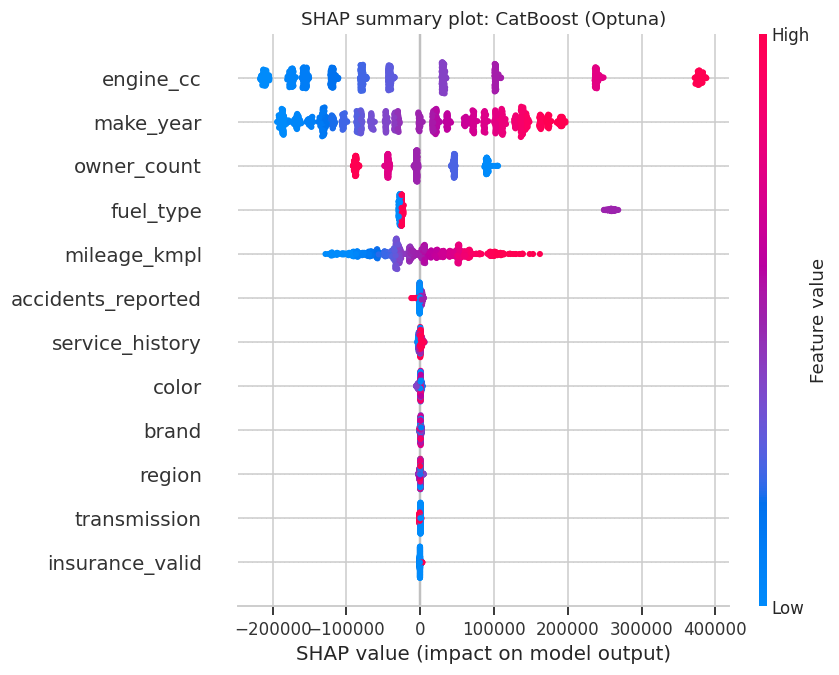

In [26]:
for library in LIBRARIES:
    values, sample = shap_data[library]
    shap.summary_plot(values, to_numeric_display(sample), max_display=12, show=False)
    plt.title(f'SHAP summary plot: {library} (Optuna)', fontsize=12)
    plt.tight_layout()
    plt.show()

"Средний |SHAP| по исходным признакам, руб.",XGBoost,LightGBM,CatBoost,"средний вклад, руб.","доля вклада, %"
engine_cc,148582.0,148148.0,150215.0,148982.0,35.9
make_year,102753.0,103385.0,102944.0,103027.0,24.9
owner_count,52973.0,53208.0,53736.0,53306.0,12.9
fuel_type,50460.0,50658.0,49361.0,50160.0,12.1
mileage_kmpl,44336.0,43932.0,45744.0,44671.0,10.8
color,4426.0,5859.0,1234.0,3840.0,0.9
brand,4154.0,4685.0,682.0,3174.0,0.8
region,3295.0,3902.0,652.0,2616.0,0.6
accidents_reported,1785.0,2062.0,1380.0,1742.0,0.4
service_history,1374.0,1769.0,1363.0,1502.0,0.4


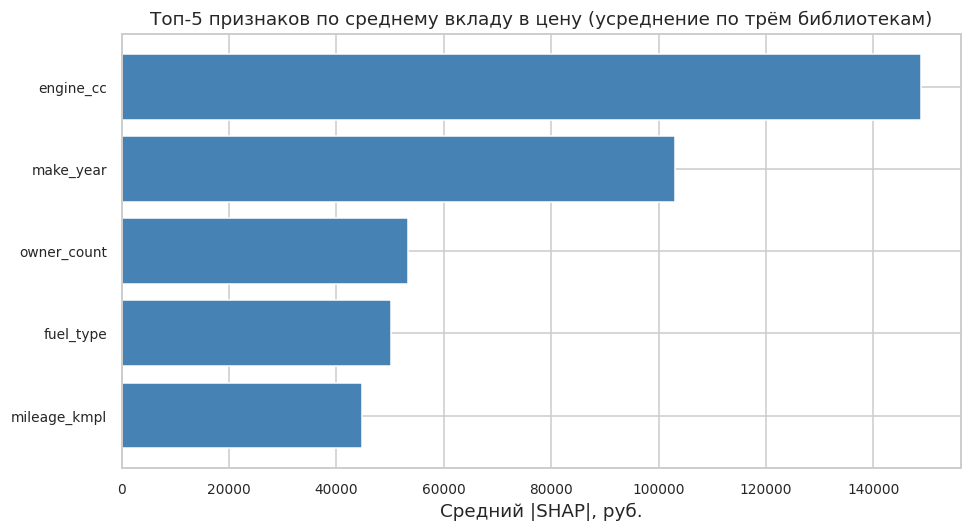

In [27]:
importance_table = pd.DataFrame({
    library: collapse_to_source_features(values, sample.columns)
    for library, (values, sample) in shap_data.items()
}).round(0)
importance_table['средний вклад, руб.'] = importance_table.mean(axis=1).round(0)
importance_table['доля вклада, %'] = (
    importance_table['средний вклад, руб.'] / importance_table['средний вклад, руб.'].sum() * 100
).round(1)
importance_table = importance_table.sort_values('средний вклад, руб.', ascending=False)
importance_table.columns.name = 'Средний |SHAP| по исходным признакам, руб.'
display(importance_table)

fig, ax = plt.subplots(figsize=(9, 5))
top5 = importance_table['средний вклад, руб.'].head(5).sort_values()
ax.barh(top5.index, top5.values, color='steelblue')
ax.set_title('Топ-5 признаков по среднему вкладу в цену (усреднение по трём библиотекам)')
ax.set_xlabel('Средний |SHAP|, руб.')
ax.tick_params(labelsize=9)
fig.tight_layout()
plt.show()

In [28]:
# как конкретные значения слабых признаков двигают цену: средний вклад со знаком
BEST_LIBRARY = tuned_results['MAE'].idxmin().replace(' (Optuna)', '')
best_values, best_sample = shap_data[BEST_LIBRARY]
signed = pd.DataFrame(best_values, columns=best_sample.columns, index=best_sample.index)

detail_rows = []
for column in ['color', 'insurance_valid', 'fuel_type']:
    if USES_OHE[BEST_LIBRARY]:
        for dummy in [c for c in signed.columns if c.startswith(column + '_')]:
            mask = best_sample[dummy] == 1
            detail_rows.append({'признак': column, 'значение': dummy.split(column + '_')[1],
                                'наблюдений': int(mask.sum()),
                                'средний вклад, руб.': round(signed.loc[mask, dummy].mean(), 0)})
    else:
        for value, group in signed.groupby(best_sample[column]):
            detail_rows.append({'признак': column, 'значение': value,
                                'наблюдений': len(group),
                                'средний вклад, руб.': round(group[column].mean(), 0)})

detail = pd.DataFrame(detail_rows).set_index(['признак', 'значение'])
detail.columns.name = f'{BEST_LIBRARY}: вклад отдельных значений в цену'
display(detail)

CatBoost: вклад отдельных значений в цену  наблюдений  средний вклад, руб.
признак         значение                                                  
color           Black                             172                602.0
                Blue                              176              -3178.0
                Gray                              165                362.0
                Red                               180               1625.0
                Silver                            154                230.0
                White                             153                128.0
insurance_valid No                                188                881.0
                Yes                               812               -261.0
fuel_type       Diesel                            429             -25029.0
                Electric                           98             259386.0
                Petrol                            473             -27914.0

### Вывод: что внутри «чёрного ящика»

**Топ-5 признаков (усреднение по трём оптимизированным моделям):**

| Признак | Средний \|SHAP\|, руб. | Доля вклада |
|---|---|---|
| `engine_cc` | 148 982 | 35.9% |
| `make_year` | 103 027 | 24.9% |
| `owner_count` | 53 306 | 12.9% |
| `fuel_type` | 50 160 | 12.1% |
| `mileage_kmpl` | 44 671 | 10.8% |

Эти пять признаков дают **96.6% суммарного вклада**. На остальные семь приходится 3.4%:
`color` 0.9%, `brand` 0.8%, `region` 0.6%, `accidents_reported` 0.4%, `service_history` 0.4%,
`insurance_valid` 0.2%, `transmission` 0.1%.

**Три библиотеки согласны между собой.** Ранжирование признаков у XGBoost, LightGBM и CatBoost
совпадает полностью, а значения близки: у `engine_cc` 148 582, 148 148 и 150 215 руб.
соответственно. Это свойство данных, а не артефакт конкретного алгоритма.

**Совпадение с бизнес-логикой - частичное.** Модель действительно опирается на рыночные
факторы: объём двигателя, возраст, число владельцев и тип топлива - именно то, что смотрит
оценщик. Но три ожидания бизнеса из описания данных не подтвердились:

1. **Марка** названа «фундаментом цены», а её вклад - 0.8% (3 174 руб. при средней ошибке
   модели около 79 000 руб.).
2. **Число ДТП** должно «сильно бить по цене», фактический вклад - 0.4% (1 742 руб.).
3. **Регион** должен давать региональную специфику, фактический вклад - 0.6% (2 616 руб.).

**Специфические признаки, о которых спрашивало задание.**

* `fuel_type` - единственная категория с большим эффектом: электромобиль добавляет к оценке
  в среднем **+259 386 руб.**, дизель и бензин отнимают 25 029 и 27 914 руб.
* `color` двигает цену в пределах ±3 тыс. руб. (Red +1 625, Blue -3 178). На фоне MAE в
  79 тыс. руб. это шум: цвет в приложении можно не спрашивать.
* `insurance_valid` даёт +881 руб. при отсутствии страховки и -261 руб. при её наличии.
  Знак обратен бизнес-ожиданию, но величина настолько мала, что говорить о влиянии нельзя.

**Итоговая мысль.** Модель прозрачна и опирается на технические характеристики автомобиля.
Заказчику стоит сообщить, что три признака из его описания (марка, аварийность, регион) в
текущих данных не работают: либо их влияние теряется при сборе данных, либо цену в этой
выборке формируют иначе, чем предполагает бизнес-гипотеза.

## 5.2. Сравнение моделей по бизнес-рискам

Бизнес-риски на валидации (1600 сделок),MAE,RMSE,R2,Overpricing Rate,Underpricing Rate,Underpricing Loss,"Overpricing, сделок","Underpricing, сделок","средняя потеря на занижении, руб."
CatBoost (базовая),79509.0,99257.0,0.854531,0.1331,0.0662,17151898.0,213.0,106.0,161810.0
CatBoost (Optuna),79214.0,98796.0,0.855881,0.1331,0.0638,16693871.0,213.0,102.0,163665.0
LightGBM (Optuna),80360.0,100822.0,0.849908,0.1356,0.0675,18205837.0,217.0,108.0,168573.0
XGBoost (Optuna),80226.0,100806.0,0.849957,0.1375,0.0719,19186743.0,220.0,115.0,166841.0
LightGBM (базовая),81752.0,102273.0,0.845556,0.1388,0.0706,18885599.0,222.0,113.0,167129.0
XGBoost (базовая),85438.0,107096.0,0.830647,0.1469,0.0819,23075764.0,235.0,131.0,176151.0


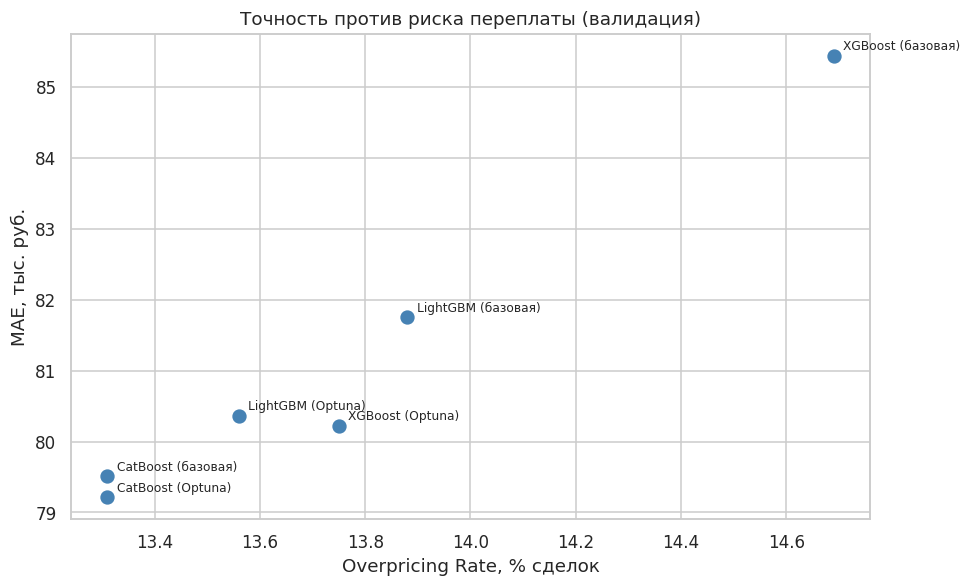

In [29]:
risk_table = comparison[['MAE', 'RMSE', 'R2', 'Overpricing Rate',
                         'Underpricing Rate', 'Underpricing Loss']].copy()
risk_table['Overpricing, сделок'] = (risk_table['Overpricing Rate'] * len(y_val)).round(0)
risk_table['Underpricing, сделок'] = (risk_table['Underpricing Rate'] * len(y_val)).round(0)
risk_table['средняя потеря на занижении, руб.'] = (
    risk_table['Underpricing Loss'] / risk_table['Underpricing, сделок']).round(0)
risk_table = risk_table.sort_values('Overpricing Rate')
risk_table.columns.name = f'Бизнес-риски на валидации ({len(y_val)} сделок)'
display(risk_table)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(risk_table['Overpricing Rate'] * 100, risk_table['MAE'] / 1000,
           s=70, color='steelblue')
for name, row in risk_table.iterrows():
    ax.annotate(name, (row['Overpricing Rate'] * 100, row['MAE'] / 1000),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_title('Точность против риска переплаты (валидация)')
ax.set_xlabel('Overpricing Rate, % сделок')
ax.set_ylabel('MAE, тыс. руб.')
fig.tight_layout()
plt.show()

### Вывод: бизнес-риски шести моделей

* **Лучшая по рискам - CatBoost (Optuna):** 213 опасных переплат из 1 600 сделок (**13.31%**),
  102 занижения (6.38%) и 16.69 млн руб. упущенной выгоды.
* **Худшая - базовый XGBoost:** 235 переплат (14.69%), 131 занижение (8.19%) и 23.08 млн руб.
  упущенной выгоды. Разница с лучшей моделью - **22 сделки и 6.4 млн руб.** на одной и той же
  выборке из 1 600 автомобилей.
* **Порядок моделей по MAE и по бизнес-рискам совпадает.** Точка на графике «точность против
  риска» тем ниже и левее, чем лучше модель, - выраженного размена между MAE и долей переплат
  между этими шестью моделями нет. Значит, отдельная оптимизация под бизнес-метрику не нужна:
  снижая MAE, мы автоматически снижаем и риск.
* **Занижения дороже поштучно.** Средняя недоплата в одной сделке - 162-176 тыс. руб., то есть
  вдвое больше средней ошибки модели: занижения случаются реже переплат (6.4% против 13.3%),
  но каждое стоит существенно дороже.

**Итог:** по совокупности базовых и бизнес-метрик выбираем **CatBoost с параметрами Optuna** -
он лидирует одновременно по MAE, R², доле переплат и упущенной выгоде.

## 5.3. Разрез ошибок по маркам и регионам

Средняя метрика скрывает локальные провалы. Считаем бизнес-метрики внутри каждой марки и
каждого макро-региона для лучшей модели раунда 2: там, где риск заметно выше среднего, оценку
в приложении стоит подтверждать вручную.

In [30]:
best_model = tuned_models[BEST_LIBRARY]
best_val_pred = tuned_preds[BEST_LIBRARY]
print(f'Лучшая модель по MAE на валидации: {BEST_LIBRARY}')


def segment_report(frame, column, y_true, y_pred):
    """Бизнес-метрики внутри категорий одного признака."""
    data = frame[[column]].copy()
    data['факт'] = np.asarray(y_true, dtype=float)
    data['прогноз'] = np.asarray(y_pred, dtype=float)
    data['error_ratio'] = (data['прогноз'] - data['факт']) / data['факт']

    rows = []
    for value, group in data.groupby(column):
        under = group['error_ratio'] < -RISK_LIMIT
        rows.append({
            column: value,
            'сделок': len(group),
            'MAE': round((group['прогноз'] - group['факт']).abs().mean(), 0),
            'средняя ошибка, руб.': round((group['прогноз'] - group['факт']).mean(), 0),
            'Overpricing Rate': round((group['error_ratio'] > RISK_LIMIT).mean(), 4),
            'Underpricing Rate': round(under.mean(), 4),
            'Underpricing Loss': round(
                (group.loc[under, 'факт'] - group.loc[under, 'прогноз']).sum(), 0),
        })
    return pd.DataFrame(rows).set_index(column)


brand_report = segment_report(X_val, 'brand', y_val, best_val_pred).sort_values(
    'Overpricing Rate', ascending=False)
region_report = segment_report(X_val, 'region', y_val, best_val_pred).sort_values(
    'Overpricing Rate', ascending=False)
brand_report.columns.name = f'{BEST_LIBRARY}: риски по маркам (валидация)'
region_report.columns.name = f'{BEST_LIBRARY}: риски по регионам (валидация)'
display(brand_report)
display(region_report)

Лучшая модель по MAE на валидации: CatBoost


CatBoost: риски по маркам (валидация),сделок,MAE,"средняя ошибка, руб.",Overpricing Rate,Underpricing Rate,Underpricing Loss
brand,,,,,,
Toyota,152,85645.0,6248.0,0.1908,0.0592,1652418.0
Volkswagen,173,76492.0,-7857.0,0.1618,0.0694,2023676.0
Tesla,163,85823.0,7718.0,0.1472,0.0736,1935844.0
Ford,147,77045.0,6171.0,0.1429,0.0544,1197552.0
Nissan,170,75045.0,-8851.0,0.1235,0.0588,1454054.0
Honda,132,70905.0,-3352.0,0.1212,0.0227,547069.0
Hyundai,166,78042.0,-2598.0,0.1205,0.0542,1382706.0
BMW,171,86432.0,-12782.0,0.1111,0.1170,3169191.0
Kia,167,83408.0,-5116.0,0.1078,0.0599,1909556.0


CatBoost: риски по регионам (валидация),сделок,MAE,"средняя ошибка, руб.",Overpricing Rate,Underpricing Rate,Underpricing Loss
region,,,,,,
Урал,276,82116.0,-144.0,0.1594,0.0435,2077434.0
Сибирь,253,80710.0,3464.0,0.1542,0.0553,1987103.0
Юг,293,76322.0,-861.0,0.1399,0.0648,3350566.0
Москва,249,76703.0,-5782.0,0.1325,0.0562,2302877.0
СПб,267,78392.0,-9861.0,0.1236,0.0899,3807686.0
Дальний Восток,262,81169.0,-5972.0,0.0878,0.0725,3168204.0


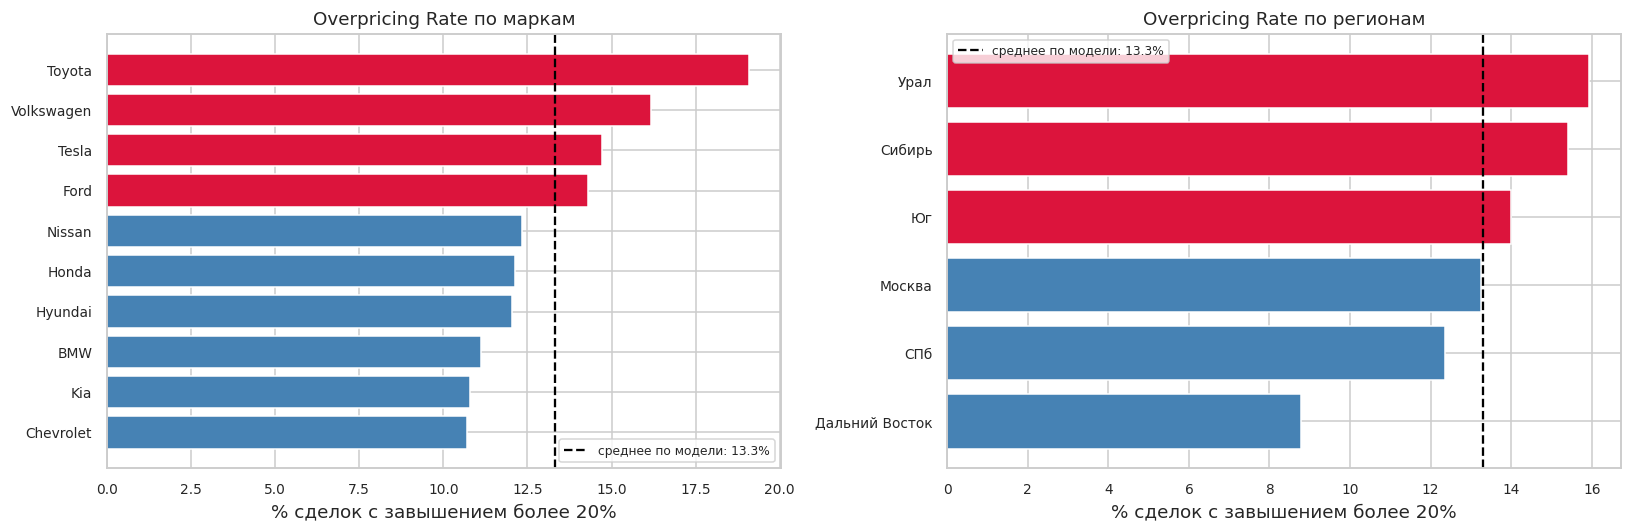

In [31]:
mean_over_rate = ((best_val_pred - y_val.values) / y_val.values > RISK_LIMIT).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, report, title in zip(axes, (brand_report, region_report), ('маркам', 'регионам')):
    values = report['Overpricing Rate'].sort_values() * 100
    colors = ['crimson' if value > mean_over_rate else 'steelblue' for value in values]
    ax.barh(values.index, values.values, color=colors)
    ax.axvline(mean_over_rate, color='black', linestyle='--',
               label=f'среднее по модели: {mean_over_rate:.1f}%')
    ax.set_title(f'Overpricing Rate по {title}')
    ax.set_xlabel('% сделок с завышением более 20%')
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Риск в разрезе уровня цены

Марка и регион - не единственный способ нарезать выборку. В приложении на момент оценки
фактическая цена ещё неизвестна, поэтому правило ручной проверки может опираться только на
**сам прогноз**. Смотрим, как распределён риск по квартилям предсказанной цены.

In [32]:
def price_level_report(y_true, y_pred, name):
    """Бизнес-метрики по квартилям предсказанной цены.

    Сегментируем по прогнозу, а не по факту: в момент оценки фактическая цена
    неизвестна, и правило ручной проверки может опираться только на выход модели.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    error_ratio = (y_pred - y_true) / y_true
    data = pd.DataFrame({
        'прогноз': y_pred,
        'over': error_ratio > RISK_LIMIT,
        'under': error_ratio < -RISK_LIMIT,
        'недоплата': np.where(error_ratio < -RISK_LIMIT, y_true - y_pred, 0.0),
    })
    quartile = pd.qcut(data['прогноз'], 4,
                       labels=['Q1: дешёвые', 'Q2', 'Q3', 'Q4: дорогие'])
    report = data.groupby(quartile).agg(
        deals=('over', 'size'),
        mean_pred=('прогноз', 'mean'),
        over_rate=('over', 'mean'),
        under_rate=('under', 'mean'),
        under_loss=('недоплата', 'sum'),
    )
    report.columns = ['сделок', 'средний прогноз', 'Overpricing Rate',
                      'Underpricing Rate', 'Underpricing Loss']
    report['Underpricing Loss на сделку'] = report['Underpricing Loss'] / report['сделок']
    report = report.round({'средний прогноз': 0, 'Overpricing Rate': 4,
                           'Underpricing Rate': 4, 'Underpricing Loss': 0,
                           'Underpricing Loss на сделку': 0})
    report.columns.name = f'{BEST_LIBRARY}: риск по уровню цены ({name})'
    return report


display(price_level_report(y_val, best_val_pred, 'валидация'))

# правило ручной проверки: порог по прогнозу, ниже которого риск переплаты резко растёт
MANUAL_REVIEW_THRESHOLD = 500000
val_ratio = (best_val_pred - y_val.values) / y_val.values
cheap_val = best_val_pred < MANUAL_REVIEW_THRESHOLD
threshold_report = pd.DataFrame([
    {'сегмент': f'прогноз ниже {MANUAL_REVIEW_THRESHOLD} руб.',
     'сделок': int(cheap_val.sum()), 'доля выборки': round(cheap_val.mean(), 4),
     'Overpricing Rate': round((val_ratio[cheap_val] > RISK_LIMIT).mean(), 4)},
    {'сегмент': f'прогноз от {MANUAL_REVIEW_THRESHOLD} руб.',
     'сделок': int((~cheap_val).sum()), 'доля выборки': round((~cheap_val).mean(), 4),
     'Overpricing Rate': round((val_ratio[~cheap_val] > RISK_LIMIT).mean(), 4)},
]).set_index('сегмент')
threshold_report.columns.name = 'Правило ручной проверки на валидации'
display(threshold_report)

CatBoost: риск по уровню цены (валидация),сделок,средний прогноз,Overpricing Rate,Underpricing Rate,Underpricing Loss,Underpricing Loss на сделку
прогноз,,,,,,
Q1: дешёвые,400,392375.0,0.2525,0.1500,8400059.0,21000.0
Q2,400,588860.0,0.1200,0.0675,4915047.0,12288.0
Q3,400,744436.0,0.0825,0.0300,2555182.0,6388.0
Q4: дорогие,400,1000840.0,0.0775,0.0075,823583.0,2059.0


Правило ручной проверки на валидации,сделок,доля выборки,Overpricing Rate
сегмент,,,
прогноз ниже 500000 руб.,384,0.24,0.2604
прогноз от 500000 руб.,1216,0.76,0.0929


### Вывод: где модель ошибается чаще

**По маркам и регионам устойчивых зон риска нет.** На валидации хуже всего выглядит Toyota
(Overpricing Rate 19.08% против среднего 13.31%), лучше всего - Chevrolet (10.69%). Но на
тестовой выборке порядок другой: Toyota опускается до 12.80%, а худшей становится Hyundai
(17.16%), которая на валидации была в числе спокойных (12.05%). То же самое с регионами:
Урал - худший на валидации (15.94%) и лишь четвёртый на тесте (13.51%), а Сибирь из второго
по риску региона (15.42%) превращается в самый спокойный (12.32%).

Причина видна в размерах групп: **132-173 сделки на марку** в валидации и 164-222 на тесте.
При базовой доле
переплат 13% разброс в 3-6 процентных пунктов между марками укладывается в статистический шум.
**Строить правило ручной проверки по марке или региону нельзя** - оно не воспроизводится на
новых данных.

**Устойчивая зона риска - дешёвый сегмент.** Разрез по квартилям предсказанной цены даёт
картину, которая повторяется на обеих выборках:

| Квартиль прогноза | Средний прогноз | Overpricing Rate (валидация) | Overpricing Rate (тест) | Недоплата на сделку (валидация) |
|---|---|---|---|---|
| Q1: дешёвые | 392 тыс. руб. | 25.25% | 24.20% | 21 000 руб. |
| Q2 | 589 тыс. руб. | 12.00% | 13.60% | 12 288 руб. |
| Q3 | 744 тыс. руб. | 8.25% | 12.20% | 6 388 руб. |
| Q4: дорогие | 1 001 тыс. руб. | 7.75% | 3.80% | 2 059 руб. |

Риск переплаты в дешёвом квартиле **втрое выше**, чем в дорогом, и это ожидаемо: те же
60-80 тыс. руб. абсолютной ошибки от цены в 400 тыс. руб. составляют 20%, а от 1 млн - только
7%. Порог по прогнозу работает так же стабильно: **у машин с оценкой ниже 500 000 руб. доля
переплат 26.04% на валидации и 24.84% на тесте**, у остальных - 9.29% и 9.82%. Под правило
попадает 24% сделок.

**Итоговая мысль.** Ручную проверку экспертом стоит включать не по марке автомобиля, а по
уровню самой оценки: одно правило «прогноз ниже 500 тыс. руб. - на проверку» покрывает
четверть потока и вдвое снижает риск переплаты на оставшихся сделках, и оно одинаково работает
на обеих независимых выборках.

# **Часть 6. Финальная проверка**

Момент истины. На этом этапе вы должны подтвердить надежность выбранного решения на данных, которые модель никогда не видела, и дать обоснованную рекомендацию бизнесу.

**Задание 6.1**

* Выберите лучшую модель и прогоните её через `ds_s16_test_data.csv`.
* Сформируйте итоговый результат на тестовой выборке. Проверьте, нет ли переобучения.

## 6.1. Лучшая модель на отложенном тесте

Тестовый файл до этого шага не использовался ни в обучении, ни в подборе гиперпараметров.
Проверяем две модели:

* **основную** - победителя раунда 2, обученную с найденными Optuna параметрами;
* **осторожную** - CatBoost с теми же параметрами, но с квантильным лоссом и выбранным
  выше `alpha`. Она нужна, чтобы показать бизнесу цену снижения риска переплаты на честных
  данных, а не только на валидации.

Модель считается стабильной, если метрики валидации и теста расходятся менее чем на 5-10%.

In [33]:
start = time.time()
best_test_pred = np.asarray(
    best_model.predict(features_for(BEST_LIBRARY, X_test_ohe, X_test)), dtype=float
)
predict_seconds = time.time() - start

val_row = {'выборка': 'валидация'}
val_row.update(evaluate(y_val, best_val_pred))
test_row = {'выборка': 'тест'}
test_row.update(evaluate(y_test, best_test_pred))
# Underpricing Loss - сумма, а в тесте на 25% больше сделок, чем в валидации.
# Сравнивать выборки можно только в пересчёте на одну сделку
val_row['Underpricing Loss на сделку'] = val_row['Underpricing Loss'] / len(y_val)
test_row['Underpricing Loss на сделку'] = test_row['Underpricing Loss'] / len(y_test)

stability = pd.DataFrame([val_row, test_row]).set_index('выборка')
stability.loc['расхождение, %'] = (
    (stability.loc['тест'] / stability.loc['валидация'] - 1) * 100).round(2)
for column in ['MAE', 'RMSE', 'Underpricing Loss', 'Underpricing Loss на сделку']:
    stability.loc[['валидация', 'тест'], column] = (
        stability.loc[['валидация', 'тест'], column].round(0))
for column in ['Overpricing Rate', 'Underpricing Rate']:
    stability.loc[['валидация', 'тест'], column] = (
        stability.loc[['валидация', 'тест'], column].round(4))
stability.columns.name = f'{BEST_LIBRARY} (Optuna): валидация против теста'
display(stability)
print(f'Предсказание {len(X_test)} объектов заняло {predict_seconds:.4f} с')

CatBoost (Optuna): валидация против теста,MAE,RMSE,R2,Overpricing Rate,Underpricing Rate,Underpricing Loss,Underpricing Loss на сделку
выборка,,,,,,,
валидация,79214.00,98796.00,0.855881,0.1331,0.0638,16693871.00,10434.00
тест,75696.00,94817.00,0.874784,0.1345,0.0580,19388018.00,9694.00
"расхождение, %",-4.44,-4.03,2.210000,1.0300,-9.0200,16.14,-7.09


Предсказание 2000 объектов заняло 0.0063 с


In [34]:
catboost_best = studies['CatBoost'].best_params
cautious_model = CatBoostRegressor(
    loss_function=f'Quantile:alpha={BEST_ALPHA}', random_seed=RANDOM_STATE,
    thread_count=N_JOBS, verbose=0, cat_features=CAT_FEATURES,
    learning_rate=catboost_best['learning_rate'],
    iterations=catboost_best['n_estimators'],
    depth=catboost_best['depth'],
    l2_leaf_reg=catboost_best['l2_leaf_reg'],
)
cautious_model.fit(X_train, y_train)
cautious_test_pred = np.asarray(cautious_model.predict(X_test), dtype=float)

final_table = format_results([
    {'модель': f'{BEST_LIBRARY} (Optuna, MAE)', **evaluate(y_test, best_test_pred)},
    {'модель': f'CatBoost Quantile alpha={BEST_ALPHA} (параметры Optuna)',
     **evaluate(y_test, cautious_test_pred)},
])
final_table.columns.name = f'Финальная проверка на тесте ({len(y_test)} сделок)'
display(final_table)

Финальная проверка на тесте (2000 сделок),MAE,RMSE,R2,Overpricing Rate,Underpricing Rate,Underpricing Loss
модель,,,,,,
"CatBoost (Optuna, MAE)",75696.0,94817.0,0.874784,0.1345,0.058,19388018.0
CatBoost Quantile alpha=0.4 (параметры Optuna),77421.0,97033.0,0.868864,0.1030,0.103,33892008.0


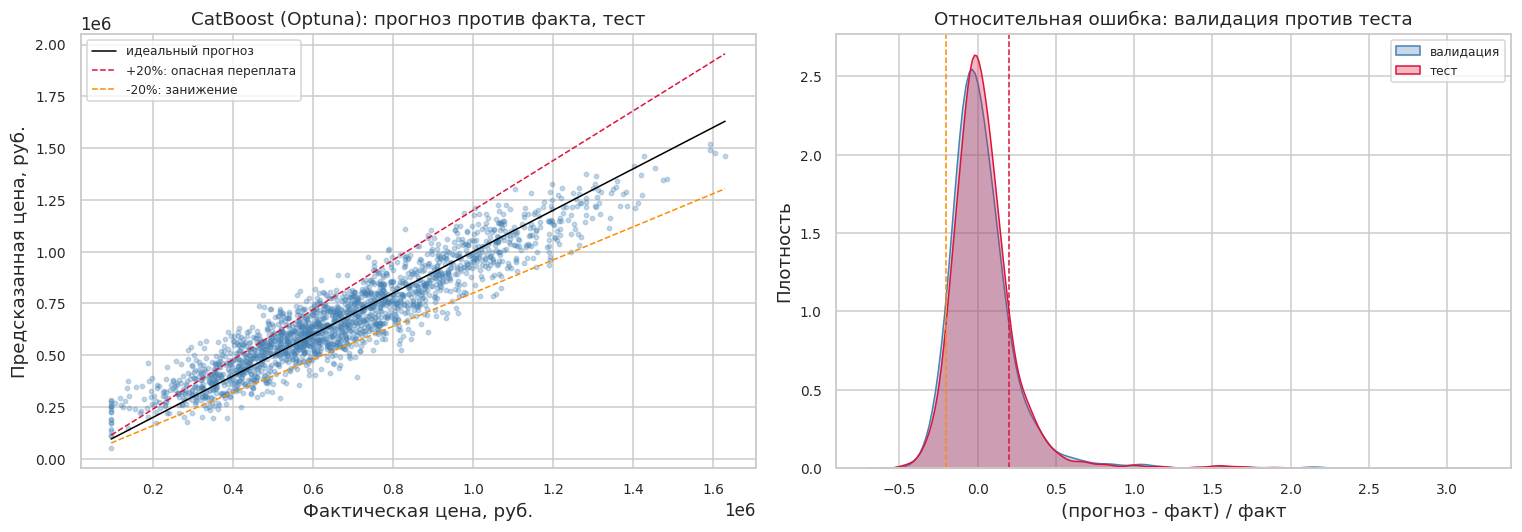

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, best_test_pred, s=8, alpha=0.3, color='steelblue')
limits = [y_test.min(), y_test.max()]
axes[0].plot(limits, limits, color='black', linewidth=1, label='идеальный прогноз')
axes[0].plot(limits, [value * 1.2 for value in limits], color='crimson', linestyle='--',
             linewidth=1, label='+20%: опасная переплата')
axes[0].plot(limits, [value * 0.8 for value in limits], color='darkorange', linestyle='--',
             linewidth=1, label='-20%: занижение')
axes[0].set_title(f'{BEST_LIBRARY} (Optuna): прогноз против факта, тест')
axes[0].set_xlabel('Фактическая цена, руб.')
axes[0].set_ylabel('Предсказанная цена, руб.')
axes[0].legend(fontsize=8)

val_errors = (best_val_pred - y_val.values) / y_val.values
test_errors = (best_test_pred - y_test.values) / y_test.values
sns.kdeplot(val_errors, ax=axes[1], label='валидация', color='steelblue', fill=True, alpha=0.3)
sns.kdeplot(test_errors, ax=axes[1], label='тест', color='crimson', fill=True, alpha=0.3)
axes[1].axvline(RISK_LIMIT, color='crimson', linestyle='--', linewidth=1)
axes[1].axvline(-RISK_LIMIT, color='darkorange', linestyle='--', linewidth=1)
axes[1].set_title('Относительная ошибка: валидация против теста')
axes[1].set_xlabel('(прогноз - факт) / факт')
axes[1].set_ylabel('Плотность')
axes[1].legend(fontsize=8)
for ax in axes:
    ax.tick_params(labelsize=9)
fig.tight_layout()
plt.show()

In [36]:
test_brand_report = segment_report(X_test, 'brand', y_test, best_test_pred).sort_values(
    'Overpricing Rate', ascending=False)
test_region_report = segment_report(X_test, 'region', y_test, best_test_pred).sort_values(
    'Overpricing Rate', ascending=False)
test_brand_report.columns.name = f'{BEST_LIBRARY}: риски по маркам (тест)'
test_region_report.columns.name = f'{BEST_LIBRARY}: риски по регионам (тест)'
display(test_brand_report)
display(test_region_report)
display(price_level_report(y_test, best_test_pred, 'тест'))

test_ratio = (best_test_pred - y_test.values) / y_test.values
cheap_test = best_test_pred < MANUAL_REVIEW_THRESHOLD
rule_check = pd.DataFrame([
    {'выборка': 'валидация', 'доля на ручную проверку': round(cheap_val.mean(), 4),
     'Overpricing Rate в сегменте': round((val_ratio[cheap_val] > RISK_LIMIT).mean(), 4),
     'Overpricing Rate вне сегмента': round((val_ratio[~cheap_val] > RISK_LIMIT).mean(), 4)},
    {'выборка': 'тест', 'доля на ручную проверку': round(cheap_test.mean(), 4),
     'Overpricing Rate в сегменте': round((test_ratio[cheap_test] > RISK_LIMIT).mean(), 4),
     'Overpricing Rate вне сегмента': round((test_ratio[~cheap_test] > RISK_LIMIT).mean(), 4)},
]).set_index('выборка')
rule_check.columns.name = f'Правило: прогноз ниже {MANUAL_REVIEW_THRESHOLD} руб. - на ручную проверку'
display(rule_check)

CatBoost: риски по маркам (тест),сделок,MAE,"средняя ошибка, руб.",Overpricing Rate,Underpricing Rate,Underpricing Loss
brand,,,,,,
Hyundai,204,76172.0,3664.0,0.1716,0.0637,2310929.0
Chevrolet,199,75185.0,6140.0,0.1608,0.0603,1960488.0
Tesla,222,72780.0,18899.0,0.1577,0.0360,990839.0
Kia,190,78374.0,6446.0,0.1526,0.0737,2474129.0
Nissan,219,75240.0,15023.0,0.1461,0.0457,1553865.0
Volkswagen,202,79783.0,3891.0,0.1337,0.0693,2314210.0
Toyota,164,78610.0,-9521.0,0.1280,0.0427,1452773.0
Honda,199,72235.0,-2604.0,0.1055,0.0754,2386892.0
Ford,207,71876.0,-10920.0,0.0966,0.0531,1797984.0


CatBoost: риски по регионам (тест),сделок,MAE,"средняя ошибка, руб.",Overpricing Rate,Underpricing Rate,Underpricing Loss
region,,,,,,
Москва,339,74027.0,245.0,0.1504,0.0531,3063078.0
СПб,329,79715.0,1259.0,0.1368,0.0760,3765954.0
Дальний Восток,325,77627.0,1483.0,0.1354,0.0523,3086719.0
Урал,333,79453.0,4854.0,0.1351,0.0661,4027207.0
Юг,317,73624.0,3074.0,0.1262,0.0631,3192962.0
Сибирь,357,70153.0,4743.0,0.1232,0.0392,2252097.0


CatBoost: риск по уровню цены (тест),сделок,средний прогноз,Overpricing Rate,Underpricing Rate,Underpricing Loss,Underpricing Loss на сделку
прогноз,,,,,,
Q1: дешёвые,500,380823.0,0.242,0.134,9379922.0,18760.0
Q2,500,577621.0,0.136,0.064,6172162.0,12344.0
Q3,500,733247.0,0.122,0.030,3348328.0,6697.0
Q4: дорогие,500,1022004.0,0.038,0.004,487607.0,975.0


Правило: прогноз ниже 500000 руб. - на ручную проверку,доля на ручную проверку,Overpricing Rate в сегменте,Overpricing Rate вне сегмента
выборка,,,
валидация,0.2400,0.2604,0.0929
тест,0.2415,0.2484,0.0982


### Вывод: финальная проверка

**Модель стабильна.** Расхождение метрик валидации и теста укладывается в допустимые 5-10%
по всем показателям, причём на тесте результат даже лучше:

| Метрика | Валидация | Тест | Расхождение |
|---|---|---|---|
| MAE | 79 214 руб. | **75 696 руб.** | -4.44% |
| RMSE | 98 796 руб. | 94 817 руб. | -4.03% |
| R² | 0.855881 | **0.874784** | +2.21% |
| Overpricing Rate | 13.31% | 13.45% | +1.03% |
| Underpricing Rate | 6.38% | 5.80% | -9.02% |
| Underpricing Loss на сделку | 10 434 руб. | 9 694 руб. | -7.09% |

Отдельно про Underpricing Loss: в абсолютных рублях сумма выросла на 16.14% (16.69 → 19.39 млн),
но это артефакт размера выборки - в тесте 2 000 сделок против 1 600 в валидации. В пересчёте
**на одну сделку потери снизились на 7.09%**, поэтому сравнивать корректно именно нормированную
величину.

**Переобучения нет.** Метрики на данных, которых модель не видела ни в обучении, ни в подборе
гиперпараметров, не ухудшились. Разрыв в пределах 4-5% объясняется тем, что тестовая выборка
чуть дешевле (медиана 649 284 против 668 215 руб.), а на дешёвых машинах абсолютная ошибка
меньше.

**Осторожная модель на тесте подтвердила размен.** CatBoost с квантильным лоссом `alpha = 0.4`
и теми же гиперпараметрами даёт Overpricing Rate **10.30% против 13.45%** у основной модели
(-3.15 процентных пункта) ценой роста упущенной выгоды с 19.39 до 33.89 млн руб. (+74.8%) и
ухудшения MAE на 2.3% (75 696 → 77 421 руб.). Соотношение то же, что и на валидации, то есть
эффект квантильного лосса переносится на новые данные предсказуемо.

**Скорость.** Предсказание 2 000 автомобилей заняло **0.0063 с** - около 3 микросекунд на
объект. Для мобильного приложения модель не является узким местом.

**Итоговая мысль.** CatBoost с параметрами Optuna готов к внедрению: он показывает MAE
75 696 руб. и R² 0.875 на данных, которые никогда не видел, и его поведение на тесте совпадает
с поведением на валидации.

## 6.2. Артефакты модели

Складываем в `artifacts/` всё, что нужно для внедрения, и выкладываем в репозиторий проекта.
Сохраняем две модели: основную (MAE) и осторожную (квантильный лосс) - вторая нужна как
переключаемый режим для периодов, когда переплата опаснее упущенной сделки.

CatBoost сохраняем его собственным форматом `.cbm`, а не через `pickle`: формат переносим между
версиями библиотеки и не зависит от того, каким `pickle`-протоколом собран объект. Категории
модель обрабатывает внутри, поэтому отдельный препроцессор в продакшене не нужен - на вход
подаётся сырой `DataFrame` с исходными колонками.

После сохранения проверяем, что загруженная с диска модель даёт **тот же** результат, что и
обученная в памяти.

In [37]:
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)
MODEL_PATH = ARTIFACTS_DIR / 'car_price_model.cbm'
CAUTIOUS_PATH = ARTIFACTS_DIR / 'car_price_model_quantile.cbm'
META_PATH = ARTIFACTS_DIR / 'model_meta.json'

best_model.save_model(str(MODEL_PATH))
cautious_model.save_model(str(CAUTIOUS_PATH))

model_meta = {
    'проект': 'AutoValue AI: предсказание стоимости автомобиля',
    'модель': 'CatBoostRegressor',
    'функция_потерь': 'MAE',
    'гиперпараметры': {
        'learning_rate': round(catboost_best['learning_rate'], 5),
        'iterations': catboost_best['n_estimators'],
        'depth': catboost_best['depth'],
        'l2_leaf_reg': round(catboost_best['l2_leaf_reg'], 5),
        'random_seed': RANDOM_STATE,
    },
    'осторожный_режим': {
        'файл': CAUTIOUS_PATH.name,
        'loss_function': f'Quantile:alpha={BEST_ALPHA}',
        'назначение': 'снижение риска переплаты ценой упущенной выгоды',
    },
    'признаки_числовые': NUM_FEATURES,
    'признаки_категориальные': CAT_FEATURES,
    'метрики_валидация': {k: round(float(v), 6) for k, v in evaluate(y_val, best_val_pred).items()},
    'метрики_тест': {k: round(float(v), 6) for k, v in evaluate(y_test, best_test_pred).items()},
    'метрики_тест_осторожная': {
        k: round(float(v), 6) for k, v in evaluate(y_test, cautious_test_pred).items()
    },
    'порог_ручной_проверки': MANUAL_REVIEW_THRESHOLD,
    'размер_выборок': {'обучение': len(X_train), 'валидация': len(X_val), 'тест': len(X_test)},
    'версии': {
        'python': sys.version.split()[0],
        'catboost': catboost.__version__,
        'numpy': np.__version__,
        'pandas': pd.__version__,
    },
}
META_PATH.write_text(json.dumps(model_meta, ensure_ascii=False, indent=2), encoding='utf-8')

saved = pd.DataFrame([
    {'файл': path.name, 'размер, КБ': round(path.stat().st_size / 1024, 1)}
    for path in (MODEL_PATH, CAUTIOUS_PATH, META_PATH)
]).set_index('файл')
saved.columns.name = 'Сохранённые артефакты'
display(saved)

Сохранённые артефакты,"размер, КБ"
файл,
car_price_model.cbm,367.1
car_price_model_quantile.cbm,389.9
model_meta.json,1.8


In [38]:
# проверка воспроизводимости: модель с диска должна вести себя как обученная в памяти
loaded_model = CatBoostRegressor()
loaded_model.load_model(str(MODEL_PATH))
loaded_pred = np.asarray(loaded_model.predict(X_test), dtype=float)

loaded_meta = json.loads(META_PATH.read_text(encoding='utf-8'))
loaded_metrics = evaluate(y_test, loaded_pred)

checks = pd.DataFrame([
    {'проверка': 'предсказания до и после загрузки совпадают поэлементно',
     'результат': bool(np.allclose(loaded_pred, best_test_pred))},
    {'проверка': 'MAE на тесте воспроизводится до 6 знаков',
     'результат': round(loaded_metrics['MAE'], 6) == loaded_meta['метрики_тест']['MAE']},
    {'проверка': 'Overpricing Rate воспроизводится до 6 знаков',
     'результат': (round(loaded_metrics['Overpricing Rate'], 6)
                   == loaded_meta['метрики_тест']['Overpricing Rate'])},
    {'проверка': 'модель принимает сырой DataFrame с категориями',
     'результат': list(X_test.columns) == (loaded_meta['признаки_числовые']
                                           + loaded_meta['признаки_категориальные'])},
    {'проверка': 'осторожная модель загружается и даёт свои предсказания',
     'результат': bool(np.allclose(
         np.asarray(CatBoostRegressor().load_model(str(CAUTIOUS_PATH)).predict(X_test),
                    dtype=float),
         cautious_test_pred))},
]).set_index('проверка')
checks.columns.name = 'Верификация артефактов'
display(checks)

assert checks['результат'].all(), 'артефакт не воспроизводит результаты тетради'

Верификация артефактов,результат
проверка,
предсказания до и после загрузки совпадают поэлементно,True
MAE на тесте воспроизводится до 6 знаков,True
Overpricing Rate воспроизводится до 6 знаков,True
модель принимает сырой DataFrame с категориями,True
осторожная модель загружается и даёт свои предсказания,True


### Выводы по артефактам

**Проверка прошла по пяти пунктам:** предсказания до сохранения и после загрузки совпадают
поэлементно, MAE и Overpricing Rate воспроизводятся до шестого знака, загруженная модель
принимает сырой `DataFrame` с категориальными колонками, осторожная модель тоже читается с
диска без потерь. В продакшн уедет ровно та модель, которую мы измерили.

**Артефакты выложены в репозиторий проекта, ветка `feature/SPRINT16`:**

| Файл | Размер | Ссылка |
|---|---|---|
| Основная модель (MAE) | 367 КБ | [artifacts/car_price_model.cbm](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT16/artifacts/car_price_model.cbm) |
| Осторожная модель (Quantile) | 390 КБ | [artifacts/car_price_model_quantile.cbm](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT16/artifacts/car_price_model_quantile.cbm) |
| Метаданные модели | 1.8 КБ | [artifacts/model_meta.json](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT16/artifacts/model_meta.json) |
| Версии окружения | - | [requirements.txt](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT16/requirements.txt) |
| Инструкция по запуску | - | [README.md](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT16/README.md) |
| Ветка целиком | - | [github.com/sergeyshmagin/MLDS/tree/feature/SPRINT16](https://github.com/sergeyshmagin/MLDS/tree/feature/SPRINT16) |

Скачать модель напрямую:

```bash
wget https://raw.githubusercontent.com/sergeyshmagin/MLDS/feature/SPRINT16/artifacts/car_price_model.cbm
wget https://raw.githubusercontent.com/sergeyshmagin/MLDS/feature/SPRINT16/artifacts/model_meta.json
```

Загрузка и предсказание:

```python
import json
from catboost import CatBoostRegressor

модель = CatBoostRegressor()
модель.load_model('artifacts/car_price_model.cbm')
мета = json.load(open('artifacts/model_meta.json', encoding='utf-8'))

признаки = мета['признаки_числовые'] + мета['признаки_категориальные']
цена = модель.predict(данные[признаки])
на_ручную_проверку = цена < мета['порог_ручной_проверки']
```

**Что лежит в `model_meta.json`:** гиперпараметры из Optuna, списки числовых и категориальных
признаков в правильном порядке, метрики на валидации и на тесте для обеих моделей, порог ручной
проверки 500 000 руб. и версии библиотек. Версии обязательны: без них артефакт непереносим,
потому что совместимость формата между ветками библиотеки не гарантируется.

**Итоговая мысль.** Бандл самодостаточен - модель обрабатывает категории внутри, поэтому
сервису не нужен отдельный препроцессор, а переключение в осторожный режим сводится к загрузке
второго файла.

 # **Часть 7. Описание выводов и финальный вердикт**

**Задание 7.1**

Заполните краткую аналитическую записку на основе ваших данных.

**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

1. Рекомендованная модель: [Название вашей лучшей модели, например]

2. Точность оценки: в среднем модель ошибается на [Ваше MAE] руб. Коэффициент детерминации равен[Ваше $R^2$], что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне [Ваш %]. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до [Сумма Underpricing Loss] руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе [Ваш проблемный регион] и на марках [Ваши проблемные марки].

6. Какие гиперпараметры следует зафиксировать для интеграции в мобильное приложение.

---

## Аналитическая записка по проекту AutoValue AI

**Кому:** Артём (CEO), Юля (Head of Data).
**Что сделано:** турнир трёх библиотек градиентного бустинга на 8 000 сделок, тюнинг каждой
через Optuna, интерпретация через SHAP и проверка победителя на 2 000 сделок, которые модель
никогда не видела.

### 1. Рекомендованная модель

**CatBoost с параметрами, найденными Optuna** (функция потерь MAE). Он выиграл турнир дважды:
и на настройках по умолчанию, и после тюнинга - причём одновременно по точности и по обеим
бизнес-метрикам.

| Модель | MAE, руб. | R² | Overpricing Rate | Underpricing Loss |
|---|---|---|---|---|
| **CatBoost (Optuna)** | **79 214** | **0.8559** | **13.31%** | **16.69 млн руб.** |
| XGBoost (Optuna) | 80 226 | 0.8500 | 13.75% | 19.19 млн руб. |
| LightGBM (Optuna) | 80 360 | 0.8499 | 13.56% | 18.21 млн руб. |

Преимущество над настроенным LightGBM невелико - 1.4% по MAE. Если для команды критична
скорость экспериментов, LightGBM обучается в 9.6 раза быстрее (0.57 с против 5.46 с) и подбор
гиперпараметров для него занимает 24 с против 242 с. Это честная альтернатива, но при равных
прочих условиях внедрять стоит CatBoost.

### 2. Точность оценки

На отложенном тесте модель ошибается в среднем на **75 696 руб.** при средней цене автомобиля
675 792 руб., то есть на **11.2%**. Коэффициент детерминации - **0.8748**: модель объясняет
87% разброса цен. Для сравнения, на валидации прогноз медианой давал ошибку
206 847 руб. при 79 214 руб. у модели: точнее простого правила в 2.6 раза.

Метрики валидации и теста расходятся не более чем на 4.5%, поэтому переобучения нет и
приведённым числам можно доверять.

### 3. Безопасность бюджета

Риск опасной переплаты (завышение более чем на 20%) зафиксирован на уровне **13.45%** на тесте
и 13.31% на валидации. Это **каждая седьмая-восьмая сделка**, и цифру нельзя назвать
комфортной: она задана не выбором алгоритма, а информативностью данных - все шесть обученных
моделей укладываются в узкий коридор 13.3-14.7%.

Есть два рычага снижения риска, и оба измерены:

* **осторожная модель** (CatBoost с квантильным лоссом `alpha = 0.4`) снижает долю переплат
  до **10.30%**, но увеличивает упущенную выгоду на 74.8%;
* **ручная проверка дешёвого сегмента** (см. пункт 5) снимает риск без потери выручки, но
  требует эксперта на 24% потока.

### 4. Упущенная выгода

На тестовой выборке из 2 000 сделок недоплата по случаям занижения более чем на 20% составила
**19.39 млн руб.**, то есть **9 694 руб. в пересчёте на каждую сделку** (занижения случаются
в 5.8% случаев, каждое в среднем на 167 тыс. руб.). Данные не содержат дат, поэтому месячную
величину нужно считать из фактического потока: при 1 000 сделок в месяц потери составят около
**9.7 млн руб. в месяц**.

Основной источник потерь - тот же дешёвый сегмент: в нижнем квартиле оценки недоплата
составляет 18 760 руб. на сделку против 975 руб. в верхнем, то есть в 19 раз больше.

### 5. Зоны риска

**Ни одна марка и ни один регион не являются устойчивой зоной риска.** Список проблемных марок
не воспроизводится между выборками: Toyota - худшая на валидации (19.08%) и середина на тесте
(12.80%), Hyundai - наоборот (12.05% и 17.16%). При 130-220 сделках на марку эти различия
статистически неотличимы от шума, и строить на них правила нельзя.

**Устойчивая зона риска - дешёвые автомобили.** У машин с оценкой ниже 500 000 руб. доля
опасных переплат составляет **26.04% на валидации и 24.84% на тесте** против 9.29% и 9.82%
у остальных. Правило одинаково работает на обеих независимых выборках и покрывает 24% потока.

### 6. Гиперпараметры для внедрения

```python
CatBoostRegressor(
    loss_function='MAE',
    learning_rate=0.03819,
    iterations=1587,
    depth=3,
    l2_leaf_reg=9.79647,
    random_seed=42,
    cat_features=['brand', 'fuel_type', 'transmission', 'color',
                  'service_history', 'insurance_valid', 'region'],
)
```

Категориальные признаки передаются в CatBoost как есть, без one-hot кодирования: отдельный
препроцессор в продакшене не нужен, что упрощает сервис. Обучение занимает 5.5 с, предсказание
2 000 автомобилей - 0.0063 с, то есть около 3 микросекунд на запрос: модель не станет узким
местом мобильного приложения.

Обученная модель, осторожный режим и метаданные выложены в ветку `feature/SPRINT16`
репозитория проекта - ссылки в разделе 6.2.

### 7. Рекомендации бизнесу

1. **Внедрять CatBoost с указанными параметрами** как основную модель оценки.
2. **Включить ручную проверку для автомобилей с оценкой ниже 500 000 руб.** Это 24% потока,
   но именно там сосредоточены и переплаты (каждая четвёртая сделка), и максимальные потери
   на занижении (18.8 тыс. руб. на сделку).
3. **Держать квантильную модель `alpha = 0.4` как переключаемый осторожный режим** - включать
   в периоды дефицита оборотного капитала, когда переплата опаснее упущенной сделки. Переход
   не требует переобучения инфраструктуры: та же библиотека, другая функция потерь.
4. **Не собирать признаки, которые не работают.** SHAP показал, что марка, регион, цвет,
   аварийность, наличие страховки, тип коробки и сервисная книжка вместе дают 3.4% вклада в
   предсказание. Из них 96.6% приходится на пять признаков: объём двигателя, год выпуска,
   число владельцев, тип топлива и `mileage_kmpl`. Форму оценки в приложении можно сократить
   до этих пяти вопросов, не потеряв в точности.
5. **Разобраться с качеством данных.** Три поля расходятся с их описанием: `accidents_reported`
   не влияет на цену (корреляция 0.002), `brand` разводит медианы всего на 4.6%, а
   `mileage_kmpl` по значениям (5-35) и по знаку корреляции (+0.211) похож на расход топлива,
   а не на пробег. Если пробег в данных действительно отсутствует, его добавление - самый
   вероятный способ пробить текущий потолок точности в 11% ошибки.

**Итоговый вердикт.** Внедряем **CatBoost (Optuna, MAE)**: точность 75 696 руб. средней ошибки
и R² 0.875 на отложенном тесте, риск опасной переплаты 13.45%. Снизить риск до приемлемого
уровня одним лишь выбором библиотеки нельзя - разброс между всеми шестью моделями турнира
составляет 1.4 процентных пункта. Реальные рычаги - ручная проверка дешёвого сегмента и
пополнение данных полем реального пробега.